In [1]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import scipy
import matplotlib.pyplot as plt

from typing import Optional, overload
from itertools import product
from datetime import datetime
from copy import deepcopy
import os

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

plt.rcParams["font.family"] = "Open Sans"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print("Imports loaded.")

Using device: cpu
Imports loaded.


In [2]:
GAMMA = 1.4
X_START, X_THROAT, X_LENGTH = 0.0, 0.5, 1.0
X_SHOCK_REF = 0.75  # reference/expected shock location
x_shock = 0.75  # initial single_loss_historyguess, updated after shock detection

# pseudo-time horizon: run long enough that transient has died out
T_STEADY = 5.0  # evaluate steady state at this pseudo-time
T_MAX = T_STEADY  # domain upper bound in t

BD_DELTA = 1e-5  # mask width for inlet/exit/IC point selection
EVAL_PRED_POINTS = 2000  # number of points to evaluate the final solution

# ── shock detection hyper-parameters ──────────────────────────────────────────
SHOCK_DET_POINTS = 2000
SHOCK_DET_ADAM_EPOCHS = 2000
SHOCK_DET_LBFGS_EPOCHS = 500
SHOCK_DET_ADAM_LR = 1e-3
SHOCK_DET_RESAMPLE_EVERY = 200
SHOCK_DET_PRINT_EVERY = 500
SHOCK_DET_GRAD_CLIP = 1.0
SHOCK_DET_BC_WEIGHT = 10.0
SHOCK_FORMATION_TOL = 1e-1

# ── dual-network hyper-parameters ─────────────────────────────────────────────
DUAL_NET_POINTS = 1000
DUAL_NET_TIME_SAMPLES = 200
DUAL_NET_ADAM_EPOCHS = 7000
DUAL_NET_LBFGS_EPOCHS = 500
DUAL_NET_ADAM_LR = 1e-3
DUAL_NET_SHOCK_LR = 1e-4
DUAL_NET_RESAMPLE_EVERY = 200
DUAL_NET_PRINT_EVERY = 500
DUAL_NET_GRAD_CLIP = 1.0
DUAL_NET_BC_WEIGHT = 10.0
DUAL_NET_INTERFACE_WEIGHT = 10.0
DUAL_NET_SHOCK_PRIOR_WEIGHT = 5.0

REMESH_EVERY = 600  # re-mesh every this many epochs during dual-net training
REMESH_SHIFT_TOL = 1e-3

SHOCK_DET_MODEL_NAME = "shock_det_model"
DUAL_NET_PRE_MODEL_NAME = "dual_net_pre_model"
DUAL_NET_POST_MODEL_NAME = "dual_net_post_model"
INTERFACE_MODEL_NAME = "interface_model"


@overload
def get_area(x: float) -> float: ...
@overload
def get_area(x: np.ndarray) -> np.ndarray: ...
@overload
def get_area(x: torch.Tensor) -> torch.Tensor: ...
def get_area(x):
    return 1.0 + 2.2 * (x - X_THROAT) ** 2.0


@overload
def get_d_area(x: float) -> float: ...
@overload
def get_d_area(x: np.ndarray) -> np.ndarray: ...
@overload
def get_d_area(x: torch.Tensor) -> torch.Tensor: ...
def get_d_area(x):
    return 4.4 * (x - X_THROAT)


print("Constants defined.")

Constants defined.


In [3]:
def _bisection_for_mach_no(a: float, supersonic: bool) -> float:
    def func(M):
        t = 1.0 + (GAMMA - 1.0) / 2.0 * M**2.0
        expo = (GAMMA + 1.0) / (2.0 * (GAMMA - 1.0))
        return (1.0 / M) * (2.0 / (GAMMA + 1.0) * t) ** expo - a

    low, high = (1.0 + BD_DELTA, 10.0) if supersonic else (BD_DELTA, 1.0 - BD_DELTA)
    for _ in range(300):
        mid = (low + high) / 2
        if func(mid) * func(low) < 0:
            high = mid
        else:
            low = mid
    return (low + high) / 2


class AnalyticSolution:
    def __init__(self, n_points: int = EVAL_PRED_POINTS):
        self.x_shock = X_SHOCK_REF
        self.x = np.linspace(X_START, X_START + X_LENGTH, n_points)
        self._solve()

    def _solve(self):
        x, x_shock = self.x, self.x_shock
        A = get_area(x)
        M = np.empty_like(x)

        sub_mask = x <= X_THROAT
        pre_mask = (x > X_THROAT) & (x <= x_shock)
        post_mask = x > x_shock

        for i in np.where(sub_mask)[0]:
            M[i] = _bisection_for_mach_no(A[i].item(), supersonic=False)
        for i in np.where(pre_mask)[0]:
            M[i] = _bisection_for_mach_no(A[i].item(), supersonic=True)

        M1 = _bisection_for_mach_no(get_area(x_shock), supersonic=True)
        M2 = np.sqrt(
            (1.0 + (GAMMA - 1.0) / 2.0 * M1**2.0)
            / (GAMMA * M1**2.0 - (GAMMA - 1.0) / 2.0)
        )

        p02_by_p01 = (
            (((GAMMA + 1.0) * M1**2.0) / (2.0 + (GAMMA - 1.0) * M1**2.0))
            ** (GAMMA / (GAMMA - 1.0))
        ) * (
            ((GAMMA + 1.0) / (2.0 * GAMMA * M1**2.0 - GAMMA + 1.0))
            ** (1.0 / (GAMMA - 1.0))
        )

        a_star_2_by_a_star_1 = 1.0 / p02_by_p01

        for i in np.where(post_mask)[0]:
            a_eff = A[i] / a_star_2_by_a_star_1
            M[i] = _bisection_for_mach_no(a_eff, supersonic=False)

        T0 = np.ones_like(x)
        P0 = np.where(post_mask, p02_by_p01, 1.0)
        rho0 = P0 / T0

        T = T0 / (1.0 + (GAMMA - 1.0) / 2.0 * M**2.0)
        P = P0 * (1.0 + (GAMMA - 1.0) / 2.0 * M**2.0) ** (-GAMMA / (GAMMA - 1.0))
        rho = rho0 * (1.0 + (GAMMA - 1.0) / 2.0 * M**2.0) ** (-1.0 / (GAMMA - 1.0))

        self.M, self.P, self.T, self.rho = M, P, T, rho
        self.sub_mask, self.pre_mask, self.post_mask = sub_mask, pre_mask, post_mask
        self.M1, self.M2, self.p02_by_p01 = M1, M2, p02_by_p01
    
    def data(self, region: str):
        match region:
            case "subsonic": mask = self.sub_mask
            case "supersonic": mask = self.pre_mask
            case "post-shock": mask = self.post_mask
            case _:
                raise ValueError(f"Unknown region: {region}")
        
        return self.x[mask], (self.M[mask], self.P[mask], self.T[mask], self.rho[mask])


analytic = AnalyticSolution()
_M_INLET = _bisection_for_mach_no(get_area(X_START), supersonic=False)
RHO_INLET = (1.0 + (GAMMA - 1.0) / 2.0 * _M_INLET**2.0) ** (-1.0 / (GAMMA - 1.0))
T_INLET = 1.0 / (1.0 + (GAMMA - 1.0) / 2.0 * _M_INLET**2.0)
P_INLET = RHO_INLET * T_INLET
U_INLET = _M_INLET * np.sqrt(GAMMA * T_INLET)
P_EXIT = analytic.P[-1]

print(f"P_EXIT={P_EXIT:.4f}  U_INLET={U_INLET:.4f}")
print("Analytical reference solution computed.")

P_EXIT=0.8289  U_INLET=0.4804
Analytical reference solution computed.


In [4]:
def _bisection_for_mach_no(a: float, supersonic: bool) -> float:
    def func(M):
        t = 1.0 + (GAMMA - 1.0) / 2.0 * M**2.0
        expo = (GAMMA + 1.0) / (2.0 * (GAMMA - 1.0))
        return (1.0 / M) * (2.0 / (GAMMA + 1.0) * t) ** expo - a

    low, high = (1.0 + BD_DELTA, 10.0) if supersonic else (BD_DELTA, 1.0 - BD_DELTA)
    for _ in range(300):
        mid = (low + high) / 2
        if func(mid) * func(low) < 0:
            high = mid
        else:
            low = mid
    return (low + high) / 2


def get_back_pressure_from_shock(x_shock_loc: float) -> float:
    A_shock = get_area(x_shock_loc)
    M_pre = _bisection_for_mach_no(A_shock, supersonic=True)
    p02_p01 = (
        ((GAMMA+1)*M_pre**2 / (2 + (GAMMA-1)*M_pre**2)) ** (GAMMA/(GAMMA-1))
        * ((GAMMA+1) / (2*GAMMA*M_pre**2 - (GAMMA-1))) ** (1/(GAMMA-1))
    )
    A_exit = get_area(X_LENGTH)
    M_exit = _bisection_for_mach_no(max(A_exit * p02_p01, 1.0 + 1e-6), supersonic=False)
    return (1.0 + (GAMMA-1)/2.0 * M_exit**2) ** (-GAMMA/(GAMMA-1)) * p02_p01

def get_inlet_mach() -> float:
    return _bisection_for_mach_no(get_area(X_START), supersonic=False)


P_EXIT = get_back_pressure_from_shock(X_SHOCK_REF)
_M_INLET = get_inlet_mach()
RHO_INLET = (1.0 + (GAMMA - 1.0) / 2.0 * _M_INLET**2.0) ** (-1.0 / (GAMMA - 1.0))
T_INLET = 1.0 / (1.0 + (GAMMA - 1.0) / 2.0 * _M_INLET**2.0)
P_INLET   = RHO_INLET * T_INLET
U_INLET = _M_INLET * np.sqrt(GAMMA * T_INLET)

print(f"P_EXIT={P_EXIT:.4f}  M_INLET={_M_INLET:.4f}  U_INLET={U_INLET:.4f}")
print("Reference data loaded.")

P_EXIT=0.8289  M_INLET=0.4129  U_INLET=0.4804
Reference data loaded.


In [5]:
class UnsteadyNet(nn.Module):
    """
    (x, t) -> (rho, u, P, T)
    """

    INPUT = 2
    OUTPUT = 4

    def __init__(self, hid_dim: int = 128, num_hidden: int = 3):
        super().__init__()
        layers = [nn.Linear(self.INPUT, hid_dim), nn.Tanh()]
        for _ in range(num_hidden):
            layers += [nn.Linear(hid_dim, hid_dim), nn.Tanh()]
        layers += [nn.Linear(hid_dim, self.OUTPUT)]
        self.net = nn.Sequential(*layers)
        self._init_weights()

    def _init_weights(self):
        for m in self.net:
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity="tanh")
                nn.init.zeros_(m.bias)

    def forward(self, xt: torch.Tensor):
        out = self.net(xt)
        rho_raw, u_raw, p_raw, T_raw = (
            out[:, 0:1],
            out[:, 1:2],
            out[:, 2:3],
            out[:, 3:4],
        )

        rho = nn.functional.softplus(rho_raw + 1.0)
        u = nn.functional.softplus(u_raw + 1.0)
        P = nn.functional.softplus(p_raw + 1.0)
        T = nn.functional.softplus(T_raw + 1.0)

        return torch.cat([rho, u, P, T], dim=1)


print("UnsteadyNet defined.")

UnsteadyNet defined.


In [6]:
def sample_points(
    x_low: float,
    x_high: float,
    t_low: float = 0.0,
    t_high: float = T_MAX,
    n: int = SHOCK_DET_POINTS,
    ic_frac: float = 0.05,
    bc_frac: float = 0.05,
) -> torch.Tensor:
    n_ic = max(1, int(n * ic_frac))
    n_bc = max(1, int(n * bc_frac))
    n_int = n - 2 * n_bc - n_ic

    # interior
    x_int = torch.rand(n_int, 1, device=device) * (x_high - x_low) + x_low
    t_int = torch.rand(n_int, 1, device=device) * (t_high - t_low) + t_low

    # inlet BC  (x = x_low, t ∈ [t_low, t_high])
    x_in = torch.full((n_bc, 1), x_low, device=device)
    t_in = torch.rand(n_bc, 1, device=device) * (t_high - t_low) + t_low

    # outlet BC (x = x_high, t ∈ [t_low, t_high])
    x_out = torch.full((n_bc, 1), x_high, device=device)
    t_out = torch.rand(n_bc, 1, device=device) * (t_high - t_low) + t_low

    # IC (t = 0, x ∈ [x_low, x_high])
    x_ic = torch.rand(n_ic, 1, device=device) * (x_high - x_low) + x_low
    t_ic = torch.zeros(n_ic, 1, device=device)

    xt = torch.cat(
        [
            torch.cat([x_int, t_int], dim=1),
            torch.cat([x_in, t_in], dim=1),
            torch.cat([x_out, t_out], dim=1),
            torch.cat([x_ic, t_ic], dim=1),
        ],
        dim=0,
    )

    idx = torch.randperm(xt.shape[0], device=device)
    return xt[idx].requires_grad_(True)


print("Point sampler defined.")

Point sampler defined.


In [7]:
def _grad(f: torch.Tensor, xt: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
    g = torch.autograd.grad(f.sum(), xt, create_graph=True)[0]
    return g[:, 0:1], g[:, 1:2]


class UnsteadyLoss:
    @staticmethod
    def pde(model: UnsteadyNet, xt: torch.Tensor):
        """
        - A * drho/dt - A * u * drho/dx - A * rho * du/dx - rho * u * dA/dx = 0
        - A * (rho * (du/dt + u * du/dx) + dP/dx) = 0
        - rho * A * (dT/dt + u * dT/dx) + (GAMMA - 1) * P * (A * du/dx + dA/dx * u) = 0
        - P - rho * T = 0
        """
        out = model(xt)
        rho, u, P, T = out[:, 0:1], out[:, 1:2], out[:, 2:3], out[:, 3:4]
        x = xt[:, 0:1]
        A, A_x = get_area(x), get_d_area(x)

        rho_x, rho_t = _grad(rho, xt)
        u_x, u_t = _grad(u, xt)
        P_x, _ = _grad(P, xt)
        T_x, T_t = _grad(T, xt)

        mass = A * rho_t + A * u * rho_x + A * rho * u_x + rho * u * A_x
        momentum = A * (rho * (u_t + u * u_x) + P_x)
        energy = rho * A * (T_t + u * T_x) + (GAMMA - 1.0) * P * (A * u_x + A_x * u)
        ideal = P - rho * T

        return torch.cat([mass, momentum, energy, ideal], dim=1)

    @staticmethod
    def bc(model: UnsteadyNet, xt: torch.Tensor):
        """
        Soft BCs — all boundaries enforced as MSE penalties.
        Returns scalar.

        Inlet  (x≈0):  rho=1, u=U_INLET, P=1, T=1
        Outlet (x≈1):  P=P_EXIT
        IC     (t≈0):  rho=1, u=0, P=1, T=1
        """
        out = model(xt)
        rho, u, P, T = out[:, 0], out[:, 1], out[:, 2], out[:, 3]
        x, t = xt[:, 0], xt[:, 1]

        zero = torch.tensor(0.0, device=device)

        # inlet x≈0
        in_mask = x < BD_DELTA
        inlet_loss = (
            (
                (rho[in_mask] / RHO_INLET - 1.0).pow(2).mean()
                + (u[in_mask] - U_INLET).pow(2).mean()
                + (P[in_mask] / P_INLET - 1.0).pow(2).mean()
                + (T[in_mask] / T_INLET - 1.0).pow(2).mean()
            )
            if in_mask.any()
            else zero
        )

        # outlet x≈1
        out_mask = x > 1.0 - BD_DELTA
        outlet_loss = ((P[out_mask] / P_EXIT - 1.0).pow(2).mean()) if out_mask.any() else zero

        # IC at t=0
        ic_mask = t < BD_DELTA
        ic_loss = (
            (
                (rho[ic_mask] / RHO_INLET - 1.0).pow(2).mean()
                + (u[ic_mask] / U_INLET - 0.0).pow(2).mean()
                + (P[ic_mask] / P_INLET - 1.0).pow(2).mean()
                + (T[ic_mask] / T_INLET - 1.0).pow(2).mean()
            )
            if ic_mask.any()
            else zero
        )

        return inlet_loss + outlet_loss + ic_loss

    @staticmethod
    def total(
        model: UnsteadyNet, xt: torch.Tensor
    ) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        pde_res = UnsteadyLoss.pde(model, xt)
        pde_loss = pde_res.pow(2).mean()
        bc_loss = UnsteadyLoss.bc(model, xt)
        loss = pde_loss + SHOCK_DET_BC_WEIGHT * bc_loss
        return loss, pde_loss, bc_loss


print("UnsteadyLoss defined.")

UnsteadyLoss defined.


In [8]:
class ModelHandler:
    SAVE_DIR = "saved_models"

    @staticmethod
    def save_path(name: str) -> str:
        os.makedirs(ModelHandler.SAVE_DIR, exist_ok=True)
        ts = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
        return os.path.join(ModelHandler.SAVE_DIR, f"{name}.{ts}.pt")

    @staticmethod
    def save(model: nn.Module, path: str):
        torch.save(model.state_dict(), path)
        print(f"  Saved: {path}")

    @staticmethod
    def snapshot(model: nn.Module) -> dict:
        return deepcopy(model.state_dict())

    @staticmethod
    def update_best(model, loss_val, best_loss, best_snap):
        if loss_val < best_loss:
            return loss_val, ModelHandler.snapshot(model)
        return best_loss, best_snap


print("ModelHandler defined.")

ModelHandler defined.


In [9]:
def shock_det_train(model: UnsteadyNet) -> tuple[list[tuple[float, float, float]], str]:
    history, best_loss, best_snap = [], float("inf"), {}

    # ── Adam phase ──────────────────────────────────────────────────────────
    optimizer = torch.optim.Adam(model.parameters(), lr=SHOCK_DET_ADAM_LR)
    xt = sample_points(X_START, X_START + X_LENGTH, n=SHOCK_DET_POINTS)
    print(f"[{SHOCK_DET_MODEL_NAME}] Adam phase ({SHOCK_DET_ADAM_EPOCHS} epochs)")
    for epoch in range(SHOCK_DET_ADAM_EPOCHS):
        if epoch % SHOCK_DET_RESAMPLE_EVERY == 0:
            xt = sample_points(X_START, X_START + X_LENGTH, n=SHOCK_DET_POINTS)

        optimizer.zero_grad()
        loss, pde_loss, bc_loss = UnsteadyLoss.total(model, xt)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), SHOCK_DET_GRAD_CLIP)
        optimizer.step()

        best_loss, best_snap = ModelHandler.update_best(
            model, loss.item(), best_loss, best_snap
        )
        history.append((pde_loss.item(), bc_loss.item(), loss.item()))

        if (epoch + 1) % SHOCK_DET_PRINT_EVERY == 0:
            print(
                f"  epoch {epoch+1:>{len(str(SHOCK_DET_ADAM_EPOCHS))}}/{SHOCK_DET_ADAM_EPOCHS}  "
                f"pde={pde_loss.item():.4e}  bc={bc_loss.item():.4e}  "
                f"total={loss.item():.4e}"
            )

    model.load_state_dict(best_snap)

    # ── L-BFGS phase ────────────────────────────────────────────────────────
    print(f"[{SHOCK_DET_MODEL_NAME}] L-BFGS phase ({SHOCK_DET_LBFGS_EPOCHS} epochs)…")
    xt_lbfgs = sample_points(X_START, X_START + X_LENGTH, n=SHOCK_DET_POINTS)
    lbfgs = torch.optim.LBFGS(model.parameters(), line_search_fn="strong_wolfe")
    last = {}

    def closure():
        lbfgs.zero_grad()
        loss, pde_loss, bc_loss = UnsteadyLoss.total(model, xt_lbfgs)
        loss.backward()
        last["loss"] = loss.item()
        last["pde_loss"] = pde_loss.item()
        last["bc_loss"] = bc_loss.item()
        return loss

    for epoch in range(SHOCK_DET_LBFGS_EPOCHS):
        lbfgs.step(closure)
        best_loss, best_snap = ModelHandler.update_best(
            model, last["loss"], best_loss, best_snap
        )
        history.append((last["pde_loss"], last["bc_loss"], last["loss"]))
        if (epoch + 1) % max(1, SHOCK_DET_PRINT_EVERY // 5) == 0:
            print(
                f"  L-BFGS {epoch+1:>{len(str(SHOCK_DET_LBFGS_EPOCHS))}}/{SHOCK_DET_LBFGS_EPOCHS}  "
                f"pde={last['pde_loss']:.4e}  bc={last['bc_loss']:.4e}  "
                f"total={last['loss']:.4e}"
            )

    model.load_state_dict(best_snap)
    path = ModelHandler.save_path(SHOCK_DET_MODEL_NAME)
    ModelHandler.save(model, path)
    return history, path


shock_detection_model = UnsteadyNet().to(device)
shock_det_history, shock_det_path = shock_det_train(shock_detection_model)

[shock_det_model] Adam phase (2000 epochs)
  epoch  500/2000  pde=2.3556e-02  bc=3.3408e-03  total=5.6964e-02
  epoch 1000/2000  pde=1.9837e-02  bc=1.5956e-03  total=3.5793e-02
  epoch 1500/2000  pde=1.7494e-02  bc=2.9321e-03  total=4.6815e-02
  epoch 2000/2000  pde=1.6061e-02  bc=2.1517e-03  total=3.7578e-02
[shock_det_model] L-BFGS phase (500 epochs)…
  L-BFGS 100/500  pde=1.4290e-03  bc=4.2453e-06  total=1.4714e-03
  L-BFGS 200/500  pde=9.1753e-05  bc=4.6314e-07  total=9.6384e-05
  L-BFGS 300/500  pde=4.8564e-05  bc=1.0620e-07  total=4.9626e-05
  L-BFGS 400/500  pde=3.5970e-05  bc=4.0658e-08  total=3.6376e-05
  L-BFGS 500/500  pde=3.1705e-05  bc=3.1250e-08  total=3.2017e-05
  Saved: saved_models/shock_det_model.2026-07-28_02-22-15.pt


In [10]:
def predict_shock_location(model: UnsteadyNet) -> float:
    model.eval()

    x_lin = np.linspace(X_START, X_START + X_LENGTH, EVAL_PRED_POINTS)
    x_ten = torch.tensor(x_lin, dtype=torch.float32, device=device)[:, None]
    t_ten = torch.full_like(x_ten, T_STEADY)
    xt = torch.cat([x_ten, t_ten], dim=1).requires_grad_(True)
    output = model(xt)

    u = output[:, 1]
    du_dx = torch.autograd.grad(u.sum(), xt, create_graph=False)[0][:, 0]
    du_dx_np = du_dx.detach().cpu().numpy()
    du_dx_np[x_lin <= X_THROAT] = 0.0  # mask converging section

    # Mach check
    with torch.no_grad():
        out = model(xt)
        rho_n = out[:, 0].cpu().numpy()
        u_n = out[:, 1].cpu().numpy()
        P_n = out[:, 2].cpu().numpy()
    M_n = u_n / np.sqrt(GAMMA * P_n / rho_n)
    max_M_post_throat = M_n[x_lin > X_THROAT].max()

    print(f"Max M post-throat: {max_M_post_throat:.4f}")
    if max_M_post_throat < 1.0:
        print("WARNING: no transonic solution found; using X_SHOCK_REF as fallback.")
        return X_SHOCK_REF

    # Find shock as left edge of the steepest negative-slope region
    min_idx = int(np.argmin(du_dx_np))
    threshold = SHOCK_FORMATION_TOL * du_dx_np[min_idx]
    shock_idx = min_idx
    for i in range(min_idx, 0, -1):
        if du_dx_np[i] > threshold:
            shock_idx = i
            break

    loc = float(np.clip(x_lin[shock_idx], X_THROAT, X_START + X_LENGTH))
    print(f"Detected shock at x = {loc:.6f}  (reference = {X_SHOCK_REF:.4f})")
    return loc


x_shock = predict_shock_location(shock_detection_model)

Max M post-throat: 1.3257
Detected shock at x = 0.612806  (reference = 0.7500)


In [11]:
# def save_data_from_shock_detection(model: UnsteadyNet, pathname: str):
#     os.makedirs(pathname, exist_ok=True)
#     ts = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
#     path = os.path.join(pathname, f"{pathname}.{ts}.pt")
#     ModelHandler.save(model, path)
#     print(f"  Saved model to {path}")
#     dir_path = path.rsplit("/", 1)[0]

#     df = pd.DataFrame(
#         shock_det_history, columns=["pde_loss", "bc_loss", "total_loss"]
#     )
#     df.to_csv(os.path.join(dir_path, f"{pathname}_history.csv"), index=False)
#     print(f"  Saved training history to {pathname}_history.csv")

#     x_shock_location = predict_shock_location(model)
#     with open(os.path.join(dir_path, f"{pathname}_shock_location.txt"), "w") as f:
#         f.write(f"{x_shock_location:.6f}\n")
#     print(f"  Saved shock location to {pathname}_shock_location.txt")

#     return path

# save_data_from_shock_detection(shock_detection_model, "SHOCK_SINGLE_085")


In [12]:
import matplotlib.font_manager as fm

font_path = "/home/prantik/Downloads/OpenSans-VariableFont_wdth,wght.ttf"
fm.fontManager.addfont(font_path)
plt.rcParams["font.family"] = "Open Sans"

In [13]:
# from scipy.optimize import brentq

# # ----------------------------------------------------------------------
# # 1. Gas properties and nozzle geometry (edit these for your problem)
# # ----------------------------------------------------------------------
# gamma = 1.4  # ratio of specific heats (1.4 for air)

# # Nozzle area distribution A(x)/A_throat, x in arbitrary length units.
# # Given directly as A/A* = 1 + 2.2*(x - 0.5)^2  (throat at x = 0.5, length = 1)
# x_min, x_throat, x_max = 0.0, 0.5, 1.0


# def area_ratio(x):
#     """A(x)/A_throat = 1 + 2.2*(x - 0.5)^2."""
#     x = np.asarray(x, dtype=float)
#     return 1.0 + 2.2 * (x - 0.5) ** 2


# # Build analytical references and saved-model predictions for three shock locations.
# shock_targets = [0.65, 0.75, 0.85]
# shock_targets_all = [0.65, 0.70, 0.75, 0.80, 0.85]
# x_shock_target = 0.75
# saved_model_dirs = {
#     0.65: "SHOCK_SINGLE_065",
#     0.70: "SHOCK_SINGLE_070",
#     0.75: "SHOCK_SINGLE_075",
#     0.80: "SHOCK_SINGLE_080",
#     0.85: "SHOCK_SINGLE_085",
# }


# # ----------------------------------------------------------------------
# # 2. Isentropic relations
# # ----------------------------------------------------------------------
# def area_mach_relation(M, area_ratio_target, gamma=1.4):
#     term = (2.0 / (gamma + 1.0)) * (1.0 + 0.5 * (gamma - 1.0) * M**2)
#     AoA_star = (1.0 / M) * term ** ((gamma + 1.0) / (2.0 * (gamma - 1.0)))
#     return AoA_star - area_ratio_target


# def solve_mach_from_area(area_ratio_target, gamma=1.4, subsonic=True):
#     if area_ratio_target <= 1.0 + 1e-12:
#         return 1.0
#     if subsonic:
#         lo, hi = 1e-6, 1.0 - 1e-9
#     else:
#         lo, hi = 1.0 + 1e-9, 60.0
#     return brentq(area_mach_relation, lo, hi, args=(area_ratio_target, gamma))


# def T0_over_T(M, gamma=1.4):
#     return 1.0 + 0.5 * (gamma - 1.0) * M**2


# def p_over_p0_isentropic(M, gamma=1.4):
#     return T0_over_T(M, gamma) ** (-gamma / (gamma - 1.0))


# # ----------------------------------------------------------------------
# # 3. Normal shock relations
# # ----------------------------------------------------------------------
# def normal_shock(M1, gamma=1.4):
#     """Given upstream Mach M1 (>1), return M2, p2/p1, rho2/rho1, p02/p01."""
#     M2 = np.sqrt(
#         (1.0 + 0.5 * (gamma - 1.0) * M1**2) / (gamma * M1**2 - 0.5 * (gamma - 1.0))
#     )
#     p2_p1 = 1.0 + (2.0 * gamma / (gamma + 1.0)) * (M1**2 - 1.0)
#     rho2_rho1 = ((gamma + 1.0) * M1**2) / ((gamma - 1.0) * M1**2 + 2.0)
#     p02_p01 = (rho2_rho1 ** (gamma / (gamma - 1.0))) * (
#         (gamma + 1.0) / (2.0 * gamma * M1**2 - (gamma - 1.0))
#     ) ** (1.0 / (gamma - 1.0))
#     return M2, p2_p1, rho2_rho1, p02_p01


# # ----------------------------------------------------------------------
# # 4. Build solutions along x
# # ----------------------------------------------------------------------
# n_points = 600
# x = np.linspace(x_min, x_max, n_points)
# A_ratio_x = area_ratio(x)


# def build_analytic_solution(x_shock_loc: float) -> dict[str, np.ndarray | float]:
#     A_shock_ratio = area_ratio(np.array([x_shock_loc]))[0]

#     M1_at_shock = solve_mach_from_area(A_shock_ratio, gamma, subsonic=False)
#     M2_at_shock, _, _, p02_p01 = normal_shock(M1_at_shock, gamma)

#     AoAstar_2_at_shock = area_mach_relation(M2_at_shock, 0.0, gamma) + 0.0
#     A_star2_over_Astar1 = A_shock_ratio / AoAstar_2_at_shock

#     M = np.zeros_like(x)
#     p_p0 = np.zeros_like(x)

#     for i, xi in enumerate(x):
#         Ar = A_ratio_x[i]
#         if xi <= x_throat:
#             Mi = solve_mach_from_area(Ar, gamma, subsonic=True)
#             p_p0[i] = p_over_p0_isentropic(Mi, gamma)
#         elif xi <= x_shock_loc:
#             Mi = solve_mach_from_area(Ar, gamma, subsonic=False)
#             p_p0[i] = p_over_p0_isentropic(Mi, gamma)
#         else:
#             Ar2 = Ar / A_star2_over_Astar1
#             Mi = solve_mach_from_area(Ar2, gamma, subsonic=True)
#             p_p0[i] = p_over_p0_isentropic(Mi, gamma) * p02_p01
#         M[i] = Mi  # type: ignore

#     M0_ref = float(M[0])
#     return {
#         "x_shock": x_shock_loc,
#         "M": M,
#         "p_p0": p_p0,
#         "M0_ref": M0_ref,
#         "M_M0": M / M0_ref,
#     }


# def latest_checkpoint_path(directory: str) -> str:
#     checkpoints = sorted(
#         file_name for file_name in os.listdir(directory) if file_name.endswith(".pt")
#     )
#     if not checkpoints:
#         raise FileNotFoundError(f"No checkpoint found in {directory}")
#     return os.path.join(directory, checkpoints[-1])


# def load_saved_shock_model(directory: str) -> tuple[UnsteadyNet, str]:
#     checkpoint_path = latest_checkpoint_path(directory)
#     model = UnsteadyNet().to(device)
#     state_dict = torch.load(checkpoint_path, map_location=device)
#     model.load_state_dict(state_dict)
#     model.eval()
#     return model, checkpoint_path


# def load_saved_shock_location(directory: str) -> float:
#     path = os.path.join(directory, f"{directory}_shock_location.txt")
#     with open(path, "r", encoding="utf-8") as file:
#         return float(file.read().strip())


# def load_saved_history(directory: str) -> np.ndarray:
#     path = os.path.join(directory, f"{directory}_history.csv")
#     df = pd.read_csv(path)
#     return df[["pde_loss", "bc_loss", "total_loss"]].to_numpy()


# analytic_solutions = {xs: build_analytic_solution(xs) for xs in shock_targets_all}
# ref_solution = analytic_solutions[x_shock_target]
# M0_ref = float(ref_solution["M0_ref"])

# A = 0.25
# half_height = A * (1 + 2.2 * (x - 0.5) ** 2)
# y_top = half_height
# y_bot = -half_height
# wall_thickness = 0.15
# wall_fill = "white"
# wall_edge = "#001aff"
# axis_color = "black"
# variant_colors = {
#     0.65: "red",
#     0.70: "#ff8700",
#     0.75: "blue",
#     0.80: "purple",
#     0.85: "green",
# }
# prediction_color = "blue"

# plt.rcParams["hatch.linewidth"] = 0.5
# plt.rcParams["hatch.color"] = "#001aff"


# def predict_single_network_solution(
#     model: UnsteadyNet,
#     n_points: int = EVAL_PRED_POINTS,
#     t_eval: float = T_STEADY,
# ):
#     model.eval()
#     x = np.linspace(X_START, X_START + X_LENGTH, n_points)
#     x_ten = torch.tensor(x, dtype=torch.float32, device=device)[:, None]
#     t_ten = torch.full_like(x_ten, t_eval)
#     xt = torch.cat([x_ten, t_ten], dim=1)

#     with torch.no_grad():
#         out = model(xt)
#         rho = out[:, 0].cpu().numpy()
#         u = out[:, 1].cpu().numpy()
#         P = out[:, 2].cpu().numpy()

#     M = u / np.sqrt(GAMMA * P / rho)
#     return x, M, P


# saved_models = {}
# saved_predictions = {}
# saved_histories = {}
# saved_shock_locations = {}
# for xs, directory in saved_model_dirs.items():
#     model, checkpoint_path = load_saved_shock_model(directory)
#     x_pred, M_pred, P_pred = predict_single_network_solution(model)
#     saved_models[xs] = {"model": model, "checkpoint_path": checkpoint_path}
#     saved_predictions[xs] = {
#         "x": x_pred,
#         "M": M_pred,
#         "P": P_pred,
#         "M_M0": M_pred / M0_ref,
#     }
#     saved_histories[xs] = load_saved_history(directory)
#     saved_shock_locations[xs] = load_saved_shock_location(directory)
#     print(
#         f"Loaded saved model for x_shock={xs:.2f} from {checkpoint_path}; "
#         f"detected shock={saved_shock_locations[xs]:.6f}"
#     )


# # ----------------------------------------------------------------------
# # 5. Main comparison plots only
# # ----------------------------------------------------------------------
# fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# plt.subplots_adjust(wspace=0.35)

# line1, line2, line3 = {}, {}, {}
# ax = axes[0]
# for xs in shock_targets:
#     s = analytic_solutions[xs]
#     line1 = ax.plot(
#         x, s["M_M0"], lw=2, ls="--", color=variant_colors[xs], label=f"Reference"
#     )

# for xs in shock_targets:
#     pred = saved_predictions[xs]
#     line2 = ax.plot(
#         pred["x"], pred["M_M0"], lw=2, color=variant_colors[xs], label="Prediction"
#     )

# ax.axvline(x_throat, color="gray", lw=1, linestyle=(0, (10, 4, 2, 4)))
# ax.set_xlabel(r"$x/L$", fontsize=16)
# ax.set_ylabel(r"$M^\prime$", fontsize=16, rotation="horizontal", labelpad=20)
# # ax.legend(handles=[line2[0], line1[0]], fontsize=12)
# ax.tick_params(axis='x', labelsize=16) 
# ax.tick_params(axis='y', labelsize=16)
# ax.xaxis.set_major_formatter('{x:.2f}')
# ax.yaxis.set_major_formatter('{x:.2f}')

# ax = axes[1]
# for xs in shock_targets:
#     s = analytic_solutions[xs]
#     line1 = ax.plot(
#         x, s["p_p0"], lw=2, ls="--", color=variant_colors[xs], label=f"Reference"
#     )

# for xs in shock_targets:
#     pred = saved_predictions[xs]
#     line2 = ax.plot(
#         pred["x"], pred["P"], lw=2, color=variant_colors[xs], label=f"Prediction"
#     )

# ax.axvline(x_throat, color="gray", lw=1, linestyle=(0, (10, 4, 2, 4)))
# ax.set_xlabel(r"$x/L$", fontsize=16)
# ax.set_ylabel(r"$p^\prime$", fontsize=16, rotation="horizontal", labelpad=20)
# # ax.legend(handles=[line2[0], line1[0]], fontsize=12)
# ax.tick_params(axis='x', labelsize=16) 
# ax.tick_params(axis='y', labelsize=16)
# ax.xaxis.set_major_formatter('{x:.2f}')
# ax.yaxis.set_major_formatter('{x:.2f}')

# plt.tight_layout()
# plt.savefig("./nozzle_properties_mach_pressure.svg", format="svg", transparent=True)
# plt.show()


# def predict_shock_front_and_behind(
#     model: UnsteadyNet,
#     n_points: int = EVAL_PRED_POINTS,
#     t_eval: float = T_STEADY,
# ) -> tuple[float, float]:
#     model.eval()

#     x_lin = np.linspace(X_START, X_START + X_LENGTH, n_points)
#     x_ten = torch.tensor(x_lin, dtype=torch.float32, device=device)[:, None]
#     t_ten = torch.full_like(x_ten, t_eval)
#     xt = torch.cat([x_ten, t_ten], dim=1).requires_grad_(True)
#     output = model(xt)

#     u = output[:, 1]
#     du_dx = torch.autograd.grad(u.sum(), xt, create_graph=False)[0][:, 0]
#     du_dx_np = du_dx.detach().cpu().numpy()
#     du_dx_np[x_lin <= X_THROAT] = 0.0  # mask converging section

#     min_idx = int(np.argmin(du_dx_np))
#     threshold = SHOCK_FORMATION_TOL * du_dx_np[min_idx]

#     # front edge: walk left from the steepest point until slope recovers
#     front_idx = min_idx
#     for i in range(min_idx, 0, -1):
#         if du_dx_np[i] > threshold:
#             front_idx = i
#             break

#     # behind edge: walk right from the steepest point until slope recovers
#     behind_idx = min_idx
#     for i in range(min_idx, len(du_dx_np)):
#         if du_dx_np[i] > threshold:
#             behind_idx = i
#             break

#     x_front = float(np.clip(x_lin[front_idx], X_THROAT, X_START + X_LENGTH))
#     x_behind = float(np.clip(x_lin[behind_idx], X_THROAT, X_START + X_LENGTH))
#     return x_front, x_behind

# import matplotlib.colors as mcolors


# def darken(color, factor=0.6):
#     """Return a darker version of a matplotlib color."""
#     rgb = np.array(mcolors.to_rgb(color))
#     return tuple(rgb * factor)


In [14]:
# # --- Back-pressure (last) plot, separated into its own figure ---
# fig, ax = plt.subplots(1, 1, figsize=(7, 5))


# front_xs, behind_xs, pb_preds = [], [], []
# for xs in shock_targets_all:
#     pb_ref = analytic_solutions[xs]["p_p0"][-1]  # type: ignore
#     pb_pred = saved_predictions[xs]["P"][-1]

#     x_front, x_behind = predict_shock_front_and_behind(saved_models[xs]["model"])
#     front_xs.append(x_front)
#     behind_xs.append(x_behind)
#     pb_preds.append(pb_pred)

#     # keep the individual predicted points, colored per shock-target case
#     ax.scatter(
#         pb_pred,
#         x_front,
#         s=55,
#         facecolors="none",
#         edgecolors=variant_colors[xs],
#         linewidths=2,
#         marker="o",
#         zorder=3,
#     )
#     ax.scatter(
#         pb_pred,
#         x_behind,
#         s=55,
#         color=variant_colors[xs],
#         marker="^",
#         zorder=3,
#     )
#     line3 = ax.scatter(
#         pb_ref,
#         xs,
#         s=55,
#         color=variant_colors[xs],
#         marker="x",
#         linewidths=2,
#         label="Reference",
#     )

# # sort by back-pressure so the connecting lines / shaded band are well-ordered
# order = np.argsort(pb_preds)
# pb_sorted = np.array(pb_preds)[order]
# front_sorted = np.array(front_xs)[order]
# behind_sorted = np.array(behind_xs)[order]

# (line_front,) = ax.plot(
#     pb_sorted,
#     front_sorted,
#     color="black",
#     lw=1.5,
#     zorder=2,
#     label="Predicted (rise)",
# )
# (line_behind,) = ax.plot(
#     pb_sorted,
#     behind_sorted,
#     color="black",
#     lw=1.5,
#     zorder=2,
#     label="Predicted (fall)",
# )
# ax.fill_between(
#     pb_sorted,
#     front_sorted,
#     behind_sorted,
#     facecolor=mcolors.to_rgba("black", alpha=0.1),  # low-alpha fill
#     edgecolor=darken("black", factor=0.4),
#     hatch="///",
#     linewidth=0.5,
# )


# # ax.set_xlim(x_throat, x_max)
# ax.set_xlabel(r"$p_b^\prime$", fontsize=16)
# ax.set_ylabel(r"$x/L$", rotation="horizontal", fontsize=16, labelpad=20)
# # ax.legend(handles=[line_front, line_behind, line3], fontsize=12)
# ax.tick_params(axis='x', labelsize=16) 
# ax.tick_params(axis='y', labelsize=16)
# ax.xaxis.set_major_formatter('{x:.2f}')
# ax.yaxis.set_major_formatter('{x:.2f}')

# plt.tight_layout()
# plt.savefig("./nozzle_back_pressure.svg", format="svg", transparent=True)
# plt.show()

In [15]:
# # --- Nozzle-only figure ---
# fig, ax = plt.subplots(1, 1, figsize=(6, 4))

# ax.fill_between(
#     x,
#     y_top,
#     y_top + wall_thickness,
#     facecolor=wall_fill,
#     edgecolor="#1c5a05",
#     hatch="////",
#     linewidth=0.0,
#     zorder=2,
# )
# ax.fill_between(
#     x,
#     y_bot - wall_thickness,
#     y_bot,
#     facecolor=wall_fill,
#     edgecolor="#1c5a05",
#     hatch="////",
#     linewidth=0.0,
#     zorder=2,
# )

# ax.plot(x, y_top, color=wall_edge, linewidth=1.0, zorder=3)
# ax.plot(x, y_bot, color=wall_edge, linewidth=1.0, zorder=3)

# ax.plot(
#     [0.5, 0.5],
#     [A, -A],
#     color=axis_color,
#     linestyle="--",
#     linewidth=1.0,
#     dashes=(5, 3),
#     zorder=1,
# )

# ax.plot(
#     [0.0, 0.0],
#     [A + wall_thickness, -A - wall_thickness],
#     color=axis_color,
#     linewidth=1.0,
#     zorder=1,
#     linestyle="--",
#     dashes=(10, 6),
# )
# ax.plot(
#     [1.0, 1.0],
#     [A + wall_thickness, -A - wall_thickness],
#     color=axis_color,
#     linewidth=1.0,
#     zorder=1,
#     linestyle="--",
#     dashes=(10, 6),
# )

# shock_dx = 0.0025
# for xs in shock_targets:
#     shock_half = A * (1 + 2.2 * (xs - 0.5) ** 2)
#     c = variant_colors[xs]
#     ax.plot(
#         [xs - shock_dx, xs - shock_dx],
#         [-shock_half, shock_half],
#         color=c,
#         linewidth=0.9,
#         zorder=4,
#     )
#     ax.plot(
#         [xs + shock_dx, xs + shock_dx],
#         [-shock_half, shock_half],
#         color=c,
#         linewidth=0.9,
#         zorder=4,
#     )

# # for xs in shock_targets:
# #     shock_loc = saved_shock_locations[xs]
# #     shock_half = A * (1 + 2.2 * (shock_loc - 0.5) ** 2)
# #     ax.plot(
# #         [shock_loc, shock_loc],
# #         [-shock_half, shock_half],
# #         color=variant_colors[xs],
# #         linewidth=1.2,
# #         linestyle="--",
# #         zorder=5,
# #     )
#     # ax.text(
#     #     shock_loc,
#     #     shock_half + 0.04,
#     #     f"x_shock={xs:.2f}",
#     #     color=variant_colors[xs],
#     #     ha="center",
#     #     va="bottom",
#     #     fontsize=8,
#     # )

# x_min_profile, x_max_profile = X_START, X_START + X_LENGTH
# y_min_profile = np.min(y_bot - wall_thickness)
# y_max_profile = np.max(y_top + wall_thickness)
# x_margin = 0.10 * (x_max_profile - x_min_profile)
# y_margin = 0.20 * (y_max_profile - y_min_profile)
# ax.set_xlim(x_min_profile - x_margin, x_max_profile + x_margin)
# ax.set_ylim(y_min_profile - y_margin, y_max_profile + y_margin)
# ax.axis("off")

# plt.tight_layout()
# plt.savefig("./nozzle_geometry.svg", format="svg", transparent=True)
# plt.show()

In [16]:
# # --- Loss-only figure ---
# fig, ax = plt.subplots(1, 1, figsize=(7, 5))

# for xs in shock_targets:
#     history = saved_histories[xs]
#     color = variant_colors[xs]
#     epochs = np.arange(history.shape[0])
#     ax.semilogy(epochs, history[:, 2], color=color, lw=1.3, label=f"x_shock={xs:.2f}")
#     # ax.semilogy(epochs, history[:, 0], color=color, lw=1.1, ls="--")
#     # ax.semilogy(epochs, history[:, 1], color=color, lw=1.1, ls="-.")

# ax.set_xlabel("Number of Epochs", fontsize=17)
# ax.set_ylabel("Loss", fontsize=17)
# plt.xticks(fontsize=16)
# plt.yticks(fontsize=16)
# # ax.legend(fontsize=11)
# ax.grid(False)

# plt.tight_layout()
# plt.savefig("./nozzle_loss_history.svg", format="svg", transparent=True)
# plt.show()

In [17]:
class ShockParam(nn.Module):
    def __init__(self, x: float):
        super().__init__()
        self.x_shock = nn.Parameter(torch.tensor([x], device=device))

    def clamped_x(self) -> torch.Tensor:
        return self.x_shock.clamp(X_THROAT + BD_DELTA, X_START + X_LENGTH - BD_DELTA)


class DualUnsteadyLoss:
    @staticmethod
    def _pde_single(model: UnsteadyNet, xt: torch.Tensor):
        return UnsteadyLoss.pde(model, xt)

    @staticmethod
    def _left_bc(model: UnsteadyNet, xt: torch.Tensor):
        return UnsteadyLoss.bc(model, xt)

    @staticmethod
    def _right_bc(model: UnsteadyNet, xt: torch.Tensor):
        return UnsteadyLoss.bc(model, xt)

    @staticmethod
    def interface(
        shock: ShockParam,
        net_L: UnsteadyNet,
        net_R: UnsteadyNet,
        t_pts: torch.Tensor,
    ):
        """
        moving shock with speed W = dx_s/dt:
            + rho_L*(u_L - W) = rho_R*(u_R - W)
            + rho_L*(u_L-W)^2 + P_L = rho_R*(u_R-W)^2 + P_R
            + H_L + (u_L-W)^2/2 = H_R + (u_R-W)^2/2
            - u_R > a_R
            - u_L < a_L
            - P_R < P_L
        """
        x_s = shock.clamped_x()
        x_col = x_s.detach().expand(t_pts.shape[0]).unsqueeze(1)
        t_col = t_pts.unsqueeze(1)
        xt_i = torch.cat([x_col, t_col], dim=1)

        out_L = net_L(xt_i)
        out_R = net_R(xt_i)
        rho_L, u_L, P_L = out_L[:, 0], out_L[:, 1], out_L[:, 2]
        rho_R, u_R, P_R = out_R[:, 0], out_R[:, 1], out_R[:, 2]
        A_i = get_area(x_s).expand_as(rho_L)

        H_L = GAMMA / (GAMMA - 1.0) * P_L / (rho_L + BD_DELTA)
        H_R = GAMMA / (GAMMA - 1.0) * P_R / (rho_R + BD_DELTA)

        flux_L_mass = rho_L * u_L * A_i
        flux_R_mass = rho_R * u_R * A_i
        rh_mass = (flux_L_mass - flux_R_mass).pow(2).mean()

        flux_L_mom = (rho_L * u_L**2 + P_L) * A_i
        flux_R_mom = (rho_R * u_R**2 + P_R) * A_i
        rh_mom = (flux_L_mom - flux_R_mom).pow(2).mean()

        flux_L_en = rho_L * u_L * (H_L + 0.5 * u_L**2) * A_i
        flux_R_en = rho_R * u_R * (H_R + 0.5 * u_R**2) * A_i
        rh_en = (flux_L_en - flux_R_en).pow(2).mean()

        a_L = torch.sqrt(GAMMA * P_L / (rho_L + BD_DELTA) + BD_DELTA)
        a_R = torch.sqrt(GAMMA * P_R / (rho_R + BD_DELTA) + BD_DELTA)
        sup_pre = torch.relu(a_L - u_L).pow(2).mean()
        sub_post = torch.relu(u_R - a_R).pow(2).mean()
        entropy = torch.relu(P_L - P_R).pow(2).mean()

        return rh_mass + rh_mom + rh_en + sup_pre + sub_post + entropy


print("DualUnsteadyLoss defined.")

DualUnsteadyLoss defined.


In [18]:
def dual_network_training_loop(last_x_shock: float):
    net_L = UnsteadyNet().to(device)
    net_R = UnsteadyNet().to(device)

    net_L.load_state_dict(shock_detection_model.state_dict())
    net_R.load_state_dict(shock_detection_model.state_dict())

    shock = ShockParam(last_x_shock).to(device)

    pts_L = sample_points(X_START, last_x_shock, n=DUAL_NET_POINTS)
    pts_R = sample_points(last_x_shock, X_START + X_LENGTH, n=DUAL_NET_POINTS)

    best_L, snap_L = float("inf"), {}
    best_R, snap_R = float("inf"), {}
    best_I, snap_I = float("inf"), {}
    loss_history = []

    # ── Adam fine-tune ────────────────────────────────────────────────────
    model_params = list(net_L.parameters()) + list(net_R.parameters())
    model_opt = torch.optim.Adam(model_params, lr=DUAL_NET_ADAM_LR)
    shock_opt = torch.optim.Adam(shock.parameters(), lr=DUAL_NET_SHOCK_LR)
    print(f"Dual network Adam phase ({DUAL_NET_ADAM_EPOCHS} epochs)…")

    for epoch in range(DUAL_NET_ADAM_EPOCHS):
        if epoch % DUAL_NET_RESAMPLE_EVERY == 0:
            pts_L = sample_points(X_START, last_x_shock, n=DUAL_NET_POINTS)
            pts_R = sample_points(last_x_shock, X_START + X_LENGTH, n=DUAL_NET_POINTS)

        if epoch % REMESH_EVERY == 0 and epoch > 0:
            new_xs = shock.clamped_x().item()
            if abs(new_xs - last_x_shock) > REMESH_SHIFT_TOL:
                last_x_shock = new_xs
                pts_L = sample_points(X_START, last_x_shock, n=DUAL_NET_POINTS)
                pts_R = sample_points(
                    last_x_shock, X_START + X_LENGTH, n=DUAL_NET_POINTS
                )
                print(f"  Remesh at epoch {epoch}: x_shock = {last_x_shock:.6f}")

        t_interface = torch.rand(DUAL_NET_TIME_SAMPLES, device=device) * T_MAX
        interface = DualUnsteadyLoss.interface(shock, net_L, net_R, t_interface)
        prior = (shock.clamped_x() - X_SHOCK_REF) ** 2

        pde_L = DualUnsteadyLoss._pde_single(net_L, pts_L).pow(2).mean()
        pde_R = DualUnsteadyLoss._pde_single(net_R, pts_R).pow(2).mean()

        bc_L = DualUnsteadyLoss._left_bc(net_L, pts_L)
        bc_R = DualUnsteadyLoss._right_bc(net_R, pts_R)

        loss = (
            pde_L
            + pde_R
            + DUAL_NET_BC_WEIGHT * (bc_L + bc_R)
            + DUAL_NET_INTERFACE_WEIGHT * interface
            + DUAL_NET_SHOCK_PRIOR_WEIGHT * prior
        )

        if not torch.isfinite(loss):
            if snap_L:
                net_L.load_state_dict(snap_L)
            if snap_R:
                net_R.load_state_dict(snap_R)
            if snap_I:
                shock.load_state_dict(snap_I)
            print(f"  NaN at epoch {epoch} — restored best snapshot, continuing")
            pts_L = sample_points(X_START, last_x_shock, n=DUAL_NET_POINTS)
            pts_R = sample_points(last_x_shock, X_START + X_LENGTH, n=DUAL_NET_POINTS)
            continue

        model_opt.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model_params, DUAL_NET_GRAD_CLIP)
        for p in shock.parameters():
            p.grad = None
        model_opt.step()

        shock_opt.zero_grad()
        interface2 = DualUnsteadyLoss.interface(shock, net_L, net_R, t_interface)
        prior2 = DUAL_NET_SHOCK_PRIOR_WEIGHT * (shock.clamped_x() - X_SHOCK_REF) ** 2
        shock_loss = DUAL_NET_INTERFACE_WEIGHT * interface2 + prior2
        shock_loss.backward()
        shock_opt.step()

        loss_history.append(
            (
                loss.item(),
                pde_L.item(),
                pde_R.item(),
                bc_L.item(),
                bc_R.item(),
                interface.item(),
                shock.clamped_x().item(),
            )
        )

        best_L, snap_L = ModelHandler.update_best(net_L, loss.item(), best_L, snap_L)
        best_R, snap_R = ModelHandler.update_best(net_R, loss.item(), best_R, snap_R)
        best_I, snap_I = ModelHandler.update_best(shock, loss.item(), best_I, snap_I)

        if (epoch + 1) % DUAL_NET_PRINT_EVERY == 0:
            xs = shock.clamped_x().item()
            with torch.no_grad():
                xt_s = torch.tensor([[xs, T_STEADY]], device=device)
                o_L = net_L(xt_s)
                o_R = net_R(xt_s)
                M_L = (o_L[0, 1] / torch.sqrt(GAMMA * o_L[0, 2] / o_L[0, 0])).item()
                M_R = (o_R[0, 1] / torch.sqrt(GAMMA * o_R[0, 2] / o_R[0, 0])).item()
            print(
                f"  epoch {epoch+1}/{DUAL_NET_ADAM_EPOCHS}  x_shock={xs:.5f}  "
                f"loss={loss.item():.4e}  "
                f"pde=({pde_L.item():.3e},{pde_R.item():.3e})  "
                f"bc=({bc_L.item():.3e},{bc_R.item():.3e})  "
                f"interface={interface.item():.3e}  "
                f"M@shock: pre={M_L:.3f}(>1) post={M_R:.3f}(<1)"
            )

    net_L.load_state_dict(snap_L)
    net_R.load_state_dict(snap_R)
    shock.load_state_dict(snap_I)

    # ── L-BFGS fine-tune ──────────────────────────────────────────────────
    print("Dual network L-BFGS phase…")
    pts_L_lbfgs = sample_points(X_START, last_x_shock, n=DUAL_NET_POINTS)
    pts_R_lbfgs = sample_points(last_x_shock, X_START + X_LENGTH, n=DUAL_NET_POINTS)
    t_interface_lbfgs = torch.rand(DUAL_NET_TIME_SAMPLES, device=device) * T_MAX
    last = {}

    lbfgs = torch.optim.LBFGS(
        list(net_L.parameters()) + list(net_R.parameters()) + list(shock.parameters()),
        line_search_fn="strong_wolfe",
    )

    def closure_dual():
        lbfgs.zero_grad()
        pde_L = DualUnsteadyLoss._pde_single(net_L, pts_L_lbfgs).pow(2).mean()
        pde_R = DualUnsteadyLoss._pde_single(net_R, pts_R_lbfgs).pow(2).mean()

        bc_L = DualUnsteadyLoss._left_bc(net_L, pts_L_lbfgs)
        bc_R = DualUnsteadyLoss._right_bc(net_R, pts_R_lbfgs)

        interface = DualUnsteadyLoss.interface(shock, net_L, net_R, t_interface_lbfgs)
        prior = (shock.clamped_x() - X_SHOCK_REF) ** 2

        loss = (
            pde_L
            + pde_R
            + DUAL_NET_BC_WEIGHT * (bc_L + bc_R)
            + DUAL_NET_INTERFACE_WEIGHT * interface
            + DUAL_NET_SHOCK_PRIOR_WEIGHT * prior
        )

        loss.backward()
        loss_data = (
            loss.item(),
            pde_L.item(),
            pde_R.item(),
            bc_L.item(),
            bc_R.item(),
            interface.item(),
            shock.clamped_x().item(),
        )

        last["loss"] = loss_data
        return loss

    for epoch in range(DUAL_NET_LBFGS_EPOCHS):
        lbfgs.step(closure_dual)
        loss_history.append(last["loss"])
        best_L, snap_L = ModelHandler.update_best(
            net_L, last["loss"][0], best_L, snap_L
        )
        best_R, snap_R = ModelHandler.update_best(
            net_R, last["loss"][0], best_R, snap_R
        )
        best_I, snap_I = ModelHandler.update_best(
            shock, last["loss"][0], best_I, snap_I
        )

        if (epoch + 1) % max(1, DUAL_NET_PRINT_EVERY // 10) == 0:
            xs = shock.clamped_x().item()
            with torch.no_grad():
                xt_s = torch.tensor([[xs, T_STEADY]], device=device)
                o_L = net_L(xt_s)
                o_R = net_R(xt_s)
                M_L = (o_L[0, 1] / torch.sqrt(GAMMA * o_L[0, 2] / o_L[0, 0])).item()
                M_R = (o_R[0, 1] / torch.sqrt(GAMMA * o_R[0, 2] / o_R[0, 0])).item()
            print(
                f"  epoch {epoch+1}/{DUAL_NET_LBFGS_EPOCHS}  x_shock={xs:.5f}  "
                f"loss={last['loss'][0]:.4e}  "
                f"pde=({last['loss'][1]:.3e},{last['loss'][2]:.3e})  "
                f"bc=({last['loss'][3]:.3e},{last['loss'][4]:.3e})  "
                f"interface={last['loss'][5]:.3e}  "
                f"M@shock: pre={M_L:.3f}(>1) post={M_R:.3f}(<1)"
            )

    path_L = ModelHandler.save_path(DUAL_NET_PRE_MODEL_NAME)
    path_R = ModelHandler.save_path(DUAL_NET_POST_MODEL_NAME)
    path_I = ModelHandler.save_path(INTERFACE_MODEL_NAME)
    ModelHandler.save(net_L, path_L)
    ModelHandler.save(net_R, path_R)
    ModelHandler.save(shock, path_I)

    return net_L, net_R, shock, loss_history, (path_L, path_R, path_I)


pre_shock_model, post_shock_model, shock_param, dual_loss_history, model_paths = (
    dual_network_training_loop(last_x_shock=x_shock)
)

Dual network Adam phase (7000 epochs)…
  epoch 500/7000  x_shock=0.63919  loss=3.2000e-01  pde=(2.698e-02,5.013e-02)  bc=(5.616e-03,6.398e-04)  interface=1.189e-02  M@shock: pre=1.882(>1) post=0.613(<1)
  Remesh at epoch 600: x_shock = 0.646090
  epoch 1000/7000  x_shock=0.67201  loss=1.9024e-01  pde=(9.989e-03,5.799e-02)  bc=(1.394e-04,1.153e-03)  interface=7.887e-03  M@shock: pre=1.920(>1) post=0.590(<1)
  Remesh at epoch 1200: x_shock = 0.683640
  epoch 1500/7000  x_shock=0.69863  loss=2.1654e-01  pde=(1.765e-02,4.875e-02)  bc=(3.272e-04,8.424e-04)  interface=1.252e-02  M@shock: pre=2.001(>1) post=0.577(<1)
  Remesh at epoch 1800: x_shock = 0.710775
  epoch 2000/7000  x_shock=0.71748  loss=1.5542e-01  pde=(8.440e-03,6.932e-02)  bc=(5.092e-04,1.386e-03)  interface=5.341e-03  M@shock: pre=2.138(>1) post=0.553(<1)
  Remesh at epoch 2400: x_shock = 0.727277
  epoch 2500/7000  x_shock=0.72862  loss=2.3012e-01  pde=(1.536e-02,7.258e-02)  bc=(2.029e-04,9.758e-04)  interface=1.281e-02  M@sh

KeyboardInterrupt: 

In [ ]:
def predict_final_results():
    pre_shock_model.eval()
    post_shock_model.eval()
    shock_param.eval()

    shock_at = shock_param.clamped_x().item()
    print(f"\nFinal shock location: {shock_at:.6f}  (reference: {X_SHOCK_REF:.4f})")

    x_eval_np = np.linspace(X_START, X_START + X_LENGTH, EVAL_PRED_POINTS)
    x_ten = torch.tensor(x_eval_np, dtype=torch.float32, device=device)
    t_ten = torch.full_like(x_ten, T_STEADY)
    xt_eval = torch.stack([x_ten, t_ten], dim=1)

    with torch.no_grad():
        out_pre = pre_shock_model(xt_eval[x_eval_np < shock_at])  # type: ignore
        out_post = post_shock_model(xt_eval[x_eval_np >= shock_at])  # type: ignore

    rho_pre, u_pre, P_pre, T_pre = (
        out_pre[:, 0].cpu().numpy(),
        out_pre[:, 1].cpu().numpy(),
        out_pre[:, 2].cpu().numpy(),
        out_pre[:, 3].cpu().numpy(),
    )
    rho_post, u_post, P_post, T_post = (
        out_post[:, 0].cpu().numpy(),
        out_post[:, 1].cpu().numpy(),
        out_post[:, 2].cpu().numpy(),
        out_post[:, 3].cpu().numpy(),
    )

    M_pre = u_pre / np.sqrt(GAMMA * P_pre / rho_pre)
    M_post = u_post / np.sqrt(GAMMA * P_post / rho_post)

    print(f"M at shock (pre) : {M_pre[-1]:.4f}  (expect >1)")
    print(f"M at shock (post): {M_post[0]:.4f}  (expect <1)")
    print(f"P at exit        : {P_post[-1]:.4f}  (target {P_EXIT:.4f})")

    return (
        x_eval_np,
        (rho_pre, u_pre, P_pre, T_pre, M_pre),
        (rho_post, u_post, P_post, T_post, M_post),
        shock_at,
    )


x_eval_np, pre_results, post_results, final_shock_loc = predict_final_results()


Final shock location: 0.749991  (reference: 0.7500)
M at shock (pre) : 1.4476  (expect >1)
M at shock (post): 0.7203  (expect <1)
P at exit        : 0.8285  (target 0.8289)


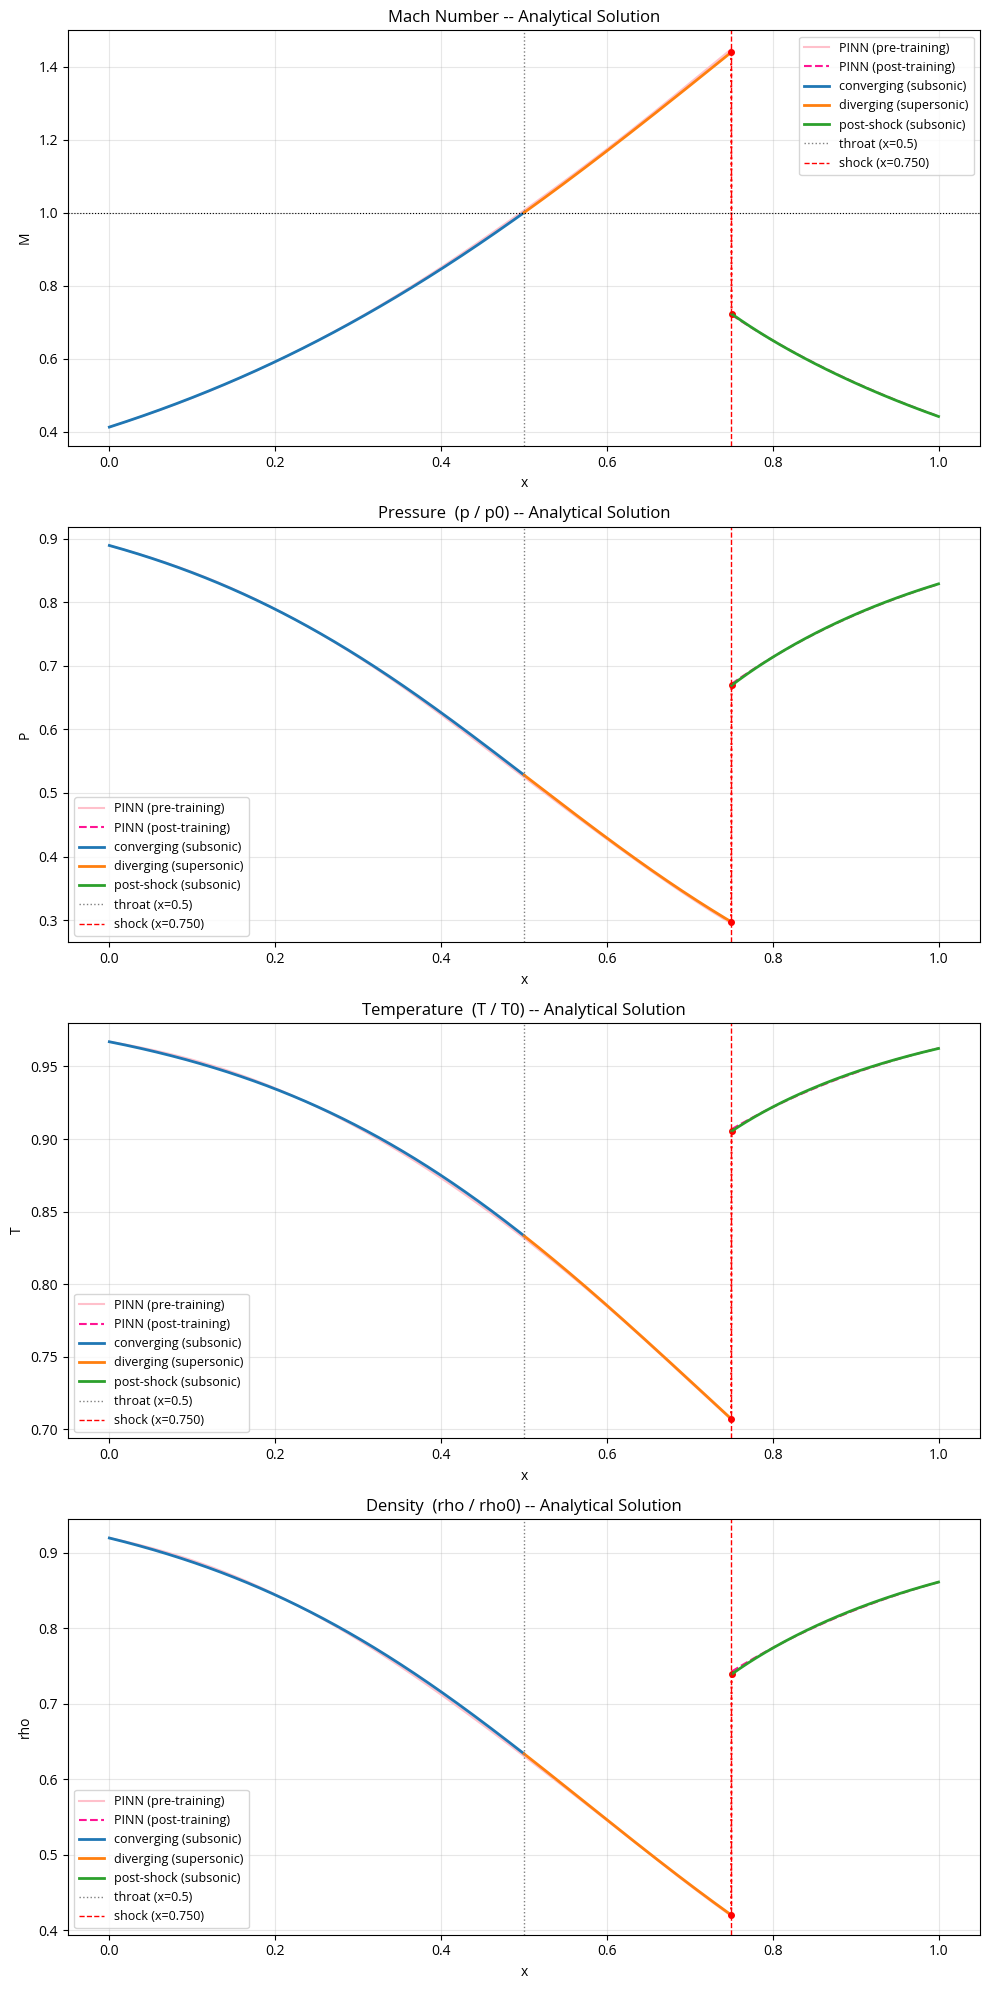

Shock at x = 0.7500
M:   1.4393 (pre-shock)  ->  0.7237 (post-shock)
P0 ratio across shock (p02/p01): 0.9478
Exit conditions: M=0.4419  P=0.8289  T=0.9624  rho=0.8613
Done.


In [20]:
fig, axes = plt.subplots(4, 1, figsize=(10, 20))

x_sub, (M_sub, P_sub, T_sub, rho_sub) = analytic.data("subsonic")
x_sup, (M_sup, P_sup, T_sup, rho_sup) = analytic.data("supersonic")
x_post, (M_post, P_post, T_post, rho_post) = analytic.data("post-shock")

panels = [
    ("Mach Number", "M", (M_sub, M_sup, M_post), [pre_results[4], post_results[4]]),
    ("Pressure  (p / p0)", "P", (P_sub, P_sup, P_post), [pre_results[2], post_results[2]]),
    ("Temperature  (T / T0)", "T", (T_sub, T_sup, T_post), [pre_results[3], post_results[3]]),
    ("Density  (rho / rho0)", "rho", (rho_sub, rho_sup, rho_post), [pre_results[0], post_results[0]]),
]



for ax, (title, ylabel, analytical, pinn) in zip(axes, panels):
    pinn_pre, pinn_post = pinn
    x_pinn_pre = x_eval_np[x_eval_np < final_shock_loc]
    x_pinn_post = x_eval_np[x_eval_np >= final_shock_loc]
    ax.plot(x_pinn_pre, pinn_pre, color="pink", label="PINN (pre-training)")
    ax.plot(x_pinn_post, pinn_post, color="deeppink", ls="--", label="PINN (post-training)")

    y_sub, y_sup, y_post = analytical
    ax.plot(x_sub, y_sub, color="tab:blue", lw=2, label="converging (subsonic)")
    ax.plot(x_sup, y_sup, color="tab:orange", lw=2, label="diverging (supersonic)")
    ax.plot(
        [x_sup[-1], x_post[0]], [y_sup[-1], y_post[0]],
        color="red", lw=1.5, ls=":", marker="o", ms=4,
    )

    ax.plot(x_post, y_post, color="tab:green", lw=2, label="post-shock (subsonic)")

    ax.axvline(X_THROAT, color="gray", ls=":", lw=1, label=f"throat (x={X_THROAT})")
    ax.axvline(
        analytic.x_shock, color="red", ls="--", lw=1,
        label=f"shock (x={analytic.x_shock:.3f})",
    )
    if title == "Mach Number":
        ax.axhline(1.0, color="black", ls=":", lw=0.8)

    ax.set_title(f"{title} -- Analytical Solution")
    ax.set_ylabel(ylabel)
    ax.set_xlabel("x")
    ax.legend(loc="best", fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("cd_nozzle_analytical_results.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Shock at x = {analytic.x_shock:.4f}")
print(f"M:   {analytic.M1:.4f} (pre-shock)  ->  {analytic.M2:.4f} (post-shock)")
print(f"P0 ratio across shock (p02/p01): {analytic.p02_by_p01:.4f}")
print(f"Exit conditions: M={M_post[-1]:.4f}  P={P_post[-1]:.4f}  T={T_post[-1]:.4f}  rho={rho_post[-1]:.4f}")
print("Done.")

In [21]:
def save_dual_net_results(pathname: str):
    os.makedirs(pathname, exist_ok=True)
    dir_path = pathname

    # model_paths already holds the checkpoints saved during dual-net training
    path_L, path_R, path_I = model_paths
    print(f"  Pre-shock model:  {path_L}")
    print(f"  Post-shock model: {path_R}")
    print(f"  Interface (shock) model: {path_I}")

    df_hist = pd.DataFrame(
        dual_loss_history,
        columns=["total", "pde_L", "pde_R", "bc_L", "bc_R", "interface", "x_shock"],
    )
    df_hist.to_csv(os.path.join(dir_path, f"{pathname}_history.csv"), index=False)
    print(f"  Saved training history to {pathname}_history.csv")

    rho_all = np.concatenate([pre_results[0], post_results[0]])
    u_all   = np.concatenate([pre_results[1], post_results[1]])
    P_all   = np.concatenate([pre_results[2], post_results[2]])
    T_all   = np.concatenate([pre_results[3], post_results[3]])
    M_all   = np.concatenate([pre_results[4], post_results[4]])

    df_pred = pd.DataFrame({
        "x": x_eval_np,
        "region": np.where(x_eval_np < final_shock_loc, "pre-shock", "post-shock"),
        "rho": rho_all, "u": u_all, "P": P_all, "T": T_all, "M": M_all,
    })
    df_pred.to_csv(os.path.join(dir_path, f"{pathname}_predictions.csv"), index=False)
    print(f"  Saved predictions to {pathname}_predictions.csv")

    with open(os.path.join(dir_path, f"{pathname}_shock_location.txt"), "w") as f:
        f.write(f"{final_shock_loc:.6f}\n")
    print(f"  Saved shock location to {pathname}_shock_location.txt")

    return dir_path


save_dual_net_results("DUAL_NET_RESULTS")

  Pre-shock model:  saved_models/dual_net_pre_model.2026-07-27_23-00-31.pt
  Post-shock model: saved_models/dual_net_post_model.2026-07-27_23-00-31.pt
  Interface (shock) model: saved_models/interface_model.2026-07-27_23-00-31.pt
  Saved training history to DUAL_NET_RESULTS_history.csv
  Saved predictions to DUAL_NET_RESULTS_predictions.csv
  Saved shock location to DUAL_NET_RESULTS_shock_location.txt


'DUAL_NET_RESULTS'

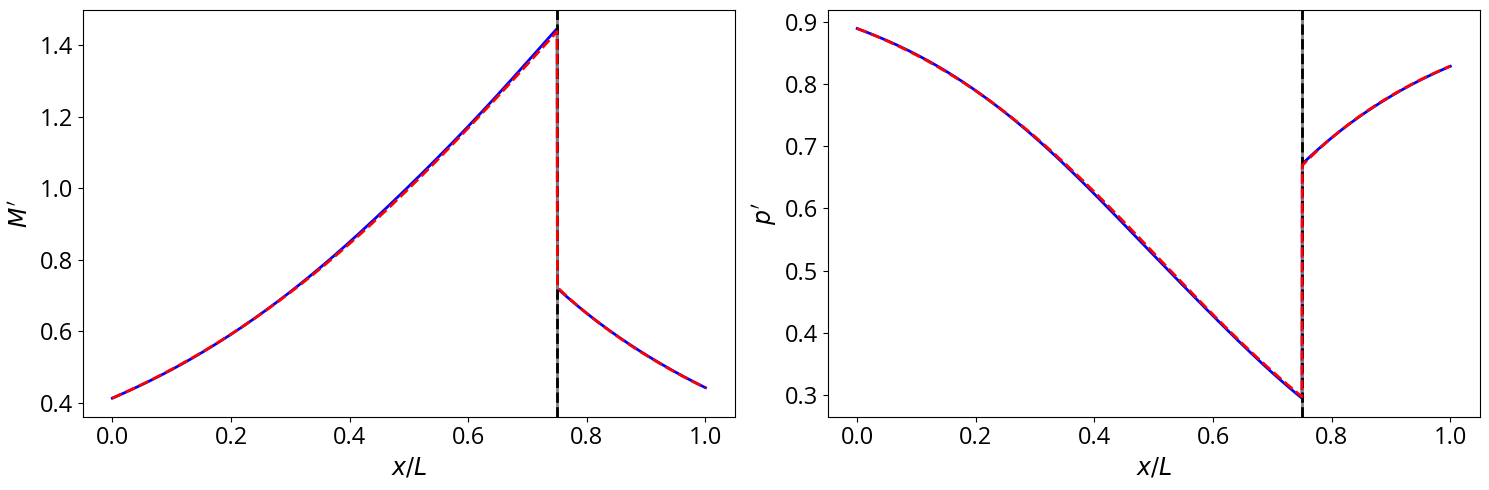

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

x_sub, (M_sub, P_sub, T_sub, rho_sub) = analytic.data("subsonic")
x_sup, (M_sup, P_sup, T_sup, rho_sup) = analytic.data("supersonic")
x_post, (M_post, P_post, T_post, rho_post) = analytic.data("post-shock")

x_ref = np.concatenate([x_sub, x_sup, x_post])
M_ref = np.concatenate([M_sub, M_sup, M_post])
P_ref = np.concatenate([P_sub, P_sup, P_post])

x_pinn = np.concatenate(
    [x_eval_np[x_eval_np < final_shock_loc], x_eval_np[x_eval_np >= final_shock_loc]]
)
M_pinn = np.concatenate([pre_results[4], post_results[4]])
P_pinn = np.concatenate([pre_results[2], post_results[2]])

panels = [
    (axes[0], M_ref, M_pinn, r"$M^\prime$"),
    (axes[1], P_ref, P_pinn, r"$p^\prime$"),
]

for ax, y_ref, y_pinn, ylabel in panels:
    ax.plot(x_pinn, y_pinn, color="blue", lw=2, zorder=2)
    ax.plot(x_ref, y_ref, color="red", ls="--", lw=2, zorder=3)
    ax.axvline(final_shock_loc, color="gray", lw=2)
    ax.axvline(X_SHOCK_REF, color="black", lw=2, ls="--")
    ax.set_xlabel(r"$x/L$", fontsize=17)
    ax.set_ylabel(ylabel, fontsize=17)
    ax.tick_params(axis="x", labelsize=17)
    ax.tick_params(axis="y", labelsize=17)
    ax.grid(False)

plt.tight_layout()
plt.savefig("cd_nozzle_M_P_results.svg", format="svg", transparent=True)
plt.show()

NameError: name 'shock_det_history' is not defined

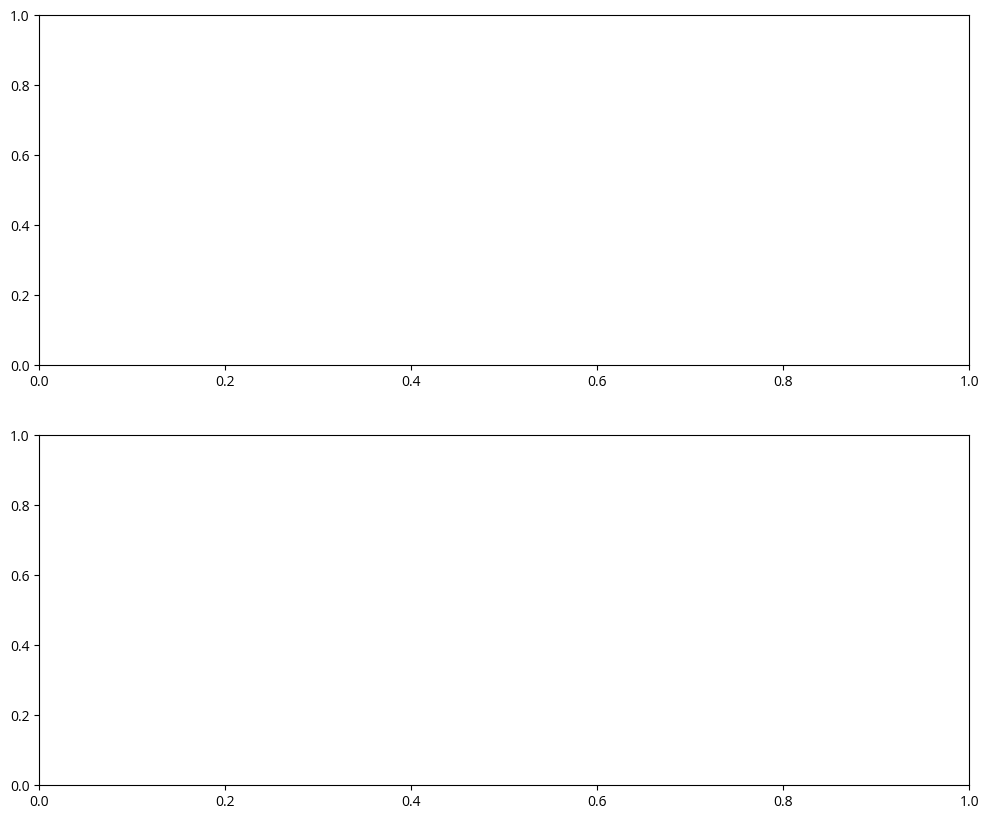

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

sd = np.array(shock_det_history)
axes[0].semilogy(sd[:, 2], color="black",      lw=1.5, label="Total")
axes[0].semilogy(sd[:, 0], color="tab:blue",   lw=1,   label="PDE", alpha=0.8)
axes[0].semilogy(sd[:, 1], color="tab:orange", lw=1,   label="BC",  alpha=0.8)
axes[0].set_title("Shock-Detection Model — Loss vs Epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss (log scale)")
axes[0].legend()
axes[0].grid(True, which="both", alpha=0.3)

dl = np.array(dual_loss_history)
axes[1].semilogy(dl[:, 0], color="black",      lw=1.5, label="Total")
axes[1].semilogy(dl[:, 1], color="tab:blue",   lw=1,   label="PDE (pre-shock)",  alpha=0.8)
axes[1].semilogy(dl[:, 2], color="tab:orange", lw=1,   label="PDE (post-shock)", alpha=0.8)
axes[1].semilogy(dl[:, 3], color="tab:green",  lw=1,   label="BC (pre-shock)",   alpha=0.8)
axes[1].semilogy(dl[:, 4], color="tab:red",    lw=1,   label="BC (post-shock)",  alpha=0.8)
axes[1].semilogy(dl[:, 5], color="purple",     lw=1,   label="Interface",        alpha=0.8)
axes[1].set_title("Dual-Network Model — Loss vs Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss (log scale)")
axes[1].legend()
axes[1].grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.savefig("loss_history.png", dpi=150, bbox_inches="tight")
plt.show()

In [8]:
# load single shock model loss history
shock_det_history = np.loadtxt("SHOCK_SINGLE_075/SHOCK_SINGLE_075_history.csv", delimiter=",", skiprows=1)
# load dual shock model loss history
dual_loss_history = np.loadtxt("DUAL_NET_RESULTS/DUAL_NET_RESULTS_history.csv", delimiter=",", skiprows=1)

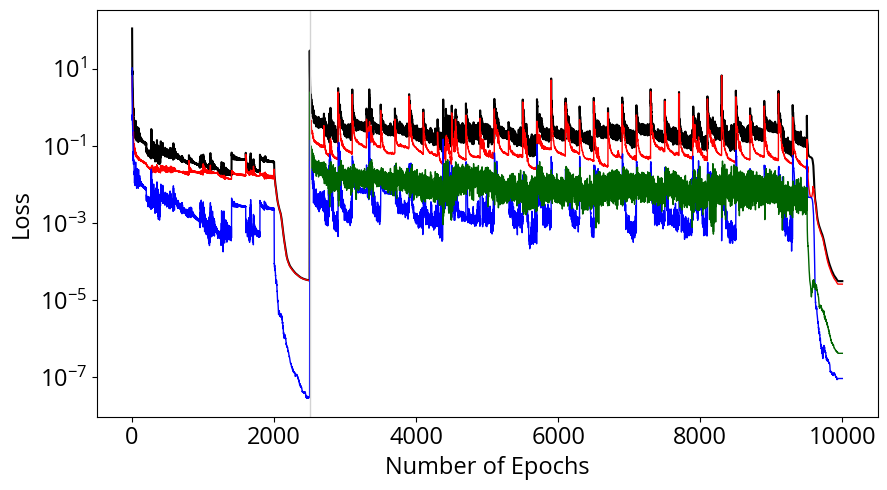

In [24]:
fig, ax = plt.subplots(1, 1, figsize=(9, 5))

sd = np.array(shock_det_history)   # columns: pde, bc, total  (single net)
dl = np.array(dual_loss_history)   # columns: total, pde_L, pde_R, bc_L, bc_R, interface, x_shock

split_at = len(sd)

total     = np.concatenate([sd[:, 2], dl[:, 0]])
pde       = np.concatenate([sd[:, 0], dl[:, 1] + dl[:, 2]])
bc        = np.concatenate([sd[:, 1], dl[:, 3] + dl[:, 4]])
interface = np.concatenate([np.full(len(sd), np.nan), dl[:, 5]])

epochs = np.arange(len(total))

ax.semilogy(epochs, total, color="black", lw=1.5)
ax.semilogy(epochs, pde, color="red", lw=1)
ax.semilogy(epochs, bc, color="blue", lw=1)
ax.semilogy(epochs, interface, color="darkgreen", lw=1)

ax.axvline(split_at, color="lightgray", lw=1)

ax.set_xlabel("Number of Epochs", fontsize=17)
ax.set_ylabel("Loss", fontsize=17)
ax.tick_params(axis="x", labelsize=17)
ax.tick_params(axis="y", labelsize=17)
ax.grid(False)

plt.tight_layout()
plt.savefig("combined_loss_history.svg", format="svg", transparent=True)
plt.show()

In [ ]:
# ── New boundary condition for shock at x = 0.9 ───────────────────────────────
X_SHOCK_NEW = 0.9
P_EXIT_NEW = get_back_pressure_from_shock(X_SHOCK_NEW)
print(f"New P_EXIT = {P_EXIT_NEW:.4f}  (was {P_EXIT:.4f})")

# Monkey-patch P_EXIT globally so all loss functions pick it up
P_EXIT = P_EXIT_NEW
X_SHOCK_REF = X_SHOCK_NEW
analytic_new = AnalyticSolution()
analytic_new.x_shock = X_SHOCK_NEW
analytic_new._solve()

# ── Helper: clone weights from an existing trained model ──────────────────────
def clone_weights(src: nn.Module, dst: nn.Module):
    dst.load_state_dict(deepcopy(src.state_dict()))

# ══════════════════════════════════════════════════════════════════════════════
# VARIANT A — full retrain from scratch (new random init)
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("VARIANT A: Retraining shock-detection model from scratch")
print("="*60)
shock_det_model_A = UnsteadyNet().to(device)
shock_det_history_A, _ = shock_det_train(shock_det_model_A)
x_shock_A = predict_shock_location(shock_det_model_A)

print("\nTraining dual network from scratch (Variant A)...")
pre_model_A, post_model_A, shock_param_A, dual_history_A, _ = dual_network_training_loop(x_shock_A)

# ══════════════════════════════════════════════════════════════════════════════
# VARIANT B — warm-start: copy old coarse (shock-detection) weights, retrain dual
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("VARIANT B: Warm-start from old shock-detection model weights")
print("="*60)
shock_det_model_B = UnsteadyNet().to(device)
clone_weights(shock_detection_model, shock_det_model_B)   # copy OLD coarse weights
shock_det_history_B, _ = shock_det_train(shock_det_model_B)
x_shock_B = predict_shock_location(shock_det_model_B)

print("\nTraining dual network warm-started from old coarse weights (Variant B)...")
pre_model_B, post_model_B, shock_param_B, dual_history_B, _ = dual_network_training_loop(x_shock_B)

In [ ]:
def dual_network_training_loop_C(label: str,
                                  init_net_L: UnsteadyNet | None = None,
                                  init_net_R: UnsteadyNet | None = None,
                                  init_shock_x: float = X_SHOCK_NEW):
    """
    Variant C  – train from scratch (init_net_L/R = None)
                 or warm-start from supplied network weights.
    Identical to dual_network_training_loop but uses X_SHOCK_NEW as prior
    centre so the shock prior pulls toward 0.9 instead of 0.75.
    """
    net_L = UnsteadyNet().to(device)
    net_R = UnsteadyNet().to(device)

    if init_net_L is not None:
        net_L.load_state_dict(init_net_L.state_dict())
        print(f"[{label}] Loaded weights into net_L from supplied model.")
    else:
        net_L.load_state_dict(shock_detection_model.state_dict())
        print(f"[{label}] Initialised net_L from shock-detection model.")

    if init_net_R is not None:
        net_R.load_state_dict(init_net_R.state_dict())
        print(f"[{label}] Loaded weights into net_R from supplied model.")
    else:
        net_R.load_state_dict(shock_detection_model.state_dict())
        print(f"[{label}] Initialised net_R from shock-detection model.")

    shock = ShockParam(init_shock_x).to(device)
    last_x_shock = init_shock_x

    pts_L = sample_points(X_START, last_x_shock, n=DUAL_NET_POINTS)
    pts_R = sample_points(last_x_shock, X_START + X_LENGTH, n=DUAL_NET_POINTS)

    best_L, snap_L = float("inf"), {}
    best_R, snap_R = float("inf"), {}
    best_I, snap_I = float("inf"), {}
    loss_history = []

    # ── Adam phase ────────────────────────────────────────────────────────────
    model_params = list(net_L.parameters()) + list(net_R.parameters())
    model_opt = torch.optim.Adam(model_params, lr=DUAL_NET_ADAM_LR)
    shock_opt = torch.optim.Adam(shock.parameters(), lr=DUAL_NET_SHOCK_LR)
    print(f"[{label}] Adam phase ({DUAL_NET_ADAM_EPOCHS} epochs)…")

    for epoch in range(DUAL_NET_ADAM_EPOCHS):
        if epoch % DUAL_NET_RESAMPLE_EVERY == 0:
            pts_L = sample_points(X_START, last_x_shock, n=DUAL_NET_POINTS)
            pts_R = sample_points(last_x_shock, X_START + X_LENGTH, n=DUAL_NET_POINTS)

        if epoch % REMESH_EVERY == 0 and epoch > 0:
            new_xs = shock.clamped_x().item()
            if abs(new_xs - last_x_shock) > REMESH_SHIFT_TOL:
                last_x_shock = new_xs
                pts_L = sample_points(X_START, last_x_shock, n=DUAL_NET_POINTS)
                pts_R = sample_points(last_x_shock, X_START + X_LENGTH, n=DUAL_NET_POINTS)
                print(f"  [{label}] Remesh at epoch {epoch}: x_shock = {last_x_shock:.6f}")

        t_interface = torch.rand(DUAL_NET_TIME_SAMPLES, device=device) * T_MAX
        interface = DualUnsteadyLoss.interface(shock, net_L, net_R, t_interface)
        prior = (shock.clamped_x() - X_SHOCK_NEW) ** 2          # <-- new prior centre

        pde_L = DualUnsteadyLoss._pde_single(net_L, pts_L).pow(2).mean()
        pde_R = DualUnsteadyLoss._pde_single(net_R, pts_R).pow(2).mean()
        bc_L  = DualUnsteadyLoss._left_bc(net_L, pts_L)
        bc_R  = DualUnsteadyLoss._right_bc(net_R, pts_R)

        loss = (
            pde_L + pde_R
            + DUAL_NET_BC_WEIGHT * (bc_L + bc_R)
            + DUAL_NET_INTERFACE_WEIGHT * interface
            + DUAL_NET_SHOCK_PRIOR_WEIGHT * prior
        )

        if not torch.isfinite(loss):
            if snap_L: net_L.load_state_dict(snap_L)
            if snap_R: net_R.load_state_dict(snap_R)
            if snap_I: shock.load_state_dict(snap_I)
            print(f"  [{label}] NaN at epoch {epoch} — restored best snapshot, continuing")
            pts_L = sample_points(X_START, last_x_shock, n=DUAL_NET_POINTS)
            pts_R = sample_points(last_x_shock, X_START + X_LENGTH, n=DUAL_NET_POINTS)
            continue

        model_opt.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model_params, DUAL_NET_GRAD_CLIP)
        for p in shock.parameters():
            p.grad = None
        model_opt.step()

        shock_opt.zero_grad()
        interface2 = DualUnsteadyLoss.interface(shock, net_L, net_R, t_interface)
        prior2 = DUAL_NET_SHOCK_PRIOR_WEIGHT * (shock.clamped_x() - X_SHOCK_NEW) ** 2
        shock_loss = DUAL_NET_INTERFACE_WEIGHT * interface2 + prior2
        shock_loss.backward()
        shock_opt.step()

        loss_history.append((
            loss.item(), pde_L.item(), pde_R.item(),
            bc_L.item(), bc_R.item(), interface.item(),
            shock.clamped_x().item(),
        ))
        best_L, snap_L = ModelHandler.update_best(net_L, loss.item(), best_L, snap_L)
        best_R, snap_R = ModelHandler.update_best(net_R, loss.item(), best_R, snap_R)
        best_I, snap_I = ModelHandler.update_best(shock, loss.item(), best_I, snap_I)

        if (epoch + 1) % DUAL_NET_PRINT_EVERY == 0:
            xs = shock.clamped_x().item()
            with torch.no_grad():
                xt_s = torch.tensor([[xs, T_STEADY]], device=device)
                o_L, o_R = net_L(xt_s), net_R(xt_s)
                M_L = (o_L[0,1] / torch.sqrt(GAMMA * o_L[0,2] / o_L[0,0])).item()
                M_R = (o_R[0,1] / torch.sqrt(GAMMA * o_R[0,2] / o_R[0,0])).item()
            print(
                f"  [{label}] epoch {epoch+1}/{DUAL_NET_ADAM_EPOCHS}  x_shock={xs:.5f}  "
                f"loss={loss.item():.4e}  "
                f"pde=({pde_L.item():.3e},{pde_R.item():.3e})  "
                f"bc=({bc_L.item():.3e},{bc_R.item():.3e})  "
                f"interface={interface.item():.3e}  "
                f"M@shock: pre={M_L:.3f}(>1) post={M_R:.3f}(<1)"
            )

    net_L.load_state_dict(snap_L)
    net_R.load_state_dict(snap_R)
    shock.load_state_dict(snap_I)

    # ── L-BFGS phase ─────────────────────────────────────────────────────────
    print(f"[{label}] L-BFGS phase ({DUAL_NET_LBFGS_EPOCHS} epochs)…")
    pts_L_lbfgs = sample_points(X_START, last_x_shock, n=DUAL_NET_POINTS)
    pts_R_lbfgs = sample_points(last_x_shock, X_START + X_LENGTH, n=DUAL_NET_POINTS)
    t_lbfgs = torch.rand(DUAL_NET_TIME_SAMPLES, device=device) * T_MAX
    last = {}

    lbfgs = torch.optim.LBFGS(
        list(net_L.parameters()) + list(net_R.parameters()) + list(shock.parameters()),
        line_search_fn="strong_wolfe",
    )

    def closure_dual():
        lbfgs.zero_grad()
        pde_L = DualUnsteadyLoss._pde_single(net_L, pts_L_lbfgs).pow(2).mean()
        pde_R = DualUnsteadyLoss._pde_single(net_R, pts_R_lbfgs).pow(2).mean()
        bc_L  = DualUnsteadyLoss._left_bc(net_L, pts_L_lbfgs)
        bc_R  = DualUnsteadyLoss._right_bc(net_R, pts_R_lbfgs)
        interface = DualUnsteadyLoss.interface(shock, net_L, net_R, t_lbfgs)
        prior = (shock.clamped_x() - X_SHOCK_NEW) ** 2          # <-- new prior centre

        loss = (
            pde_L + pde_R
            + DUAL_NET_BC_WEIGHT * (bc_L + bc_R)
            + DUAL_NET_INTERFACE_WEIGHT * interface
            + DUAL_NET_SHOCK_PRIOR_WEIGHT * prior
        )
        loss.backward()
        loss_data = (
            loss.item(), pde_L.item(), pde_R.item(),
            bc_L.item(), bc_R.item(), interface.item(),
            shock.clamped_x().item(),
        )

        loss_history.append(loss_data)
        last["loss"] = loss_data
        return loss

    for epoch in range(DUAL_NET_LBFGS_EPOCHS):
        lbfgs.step(closure_dual)
        best_L, snap_L = ModelHandler.update_best(net_L, last["loss"][0], best_L, snap_L)
        best_R, snap_R = ModelHandler.update_best(net_R, last["loss"][0], best_R, snap_R)
        best_I, snap_I = ModelHandler.update_best(shock, last["loss"][0], best_I, snap_I)

        if (epoch + 1) % max(1, DUAL_NET_PRINT_EVERY // 10) == 0:
            xs = shock.clamped_x().item()
            with torch.no_grad():
                xt_s = torch.tensor([[xs, T_STEADY]], device=device)
                o_L, o_R = net_L(xt_s), net_R(xt_s)
                M_L = (o_L[0,1] / torch.sqrt(GAMMA * o_L[0,2] / o_L[0,0])).item()
                M_R = (o_R[0,1] / torch.sqrt(GAMMA * o_R[0,2] / o_R[0,0])).item()
            print(
                f"  [{label}] L-BFGS {epoch+1}/{DUAL_NET_LBFGS_EPOCHS}  x_shock={xs:.5f}  "
                f"loss={last['loss'][0]:.4e}  "
                f"pde=({last['loss'][1]:.3e},{last['loss'][2]:.3e})  "
                f"bc=({last['loss'][3]:.3e},{last['loss'][4]:.3e})  "
                f"interface={last['loss'][5]:.3e}  "
                f"M@shock: pre={M_L:.3f}(>1) post={M_R:.3f}(<1)"
            )

    net_L.load_state_dict(snap_L)
    net_R.load_state_dict(snap_R)
    shock.load_state_dict(snap_I)

    suffix = label.lower().replace(" ", "_")
    path_L = ModelHandler.save_path(f"dual_net_pre_{suffix}")
    path_R = ModelHandler.save_path(f"dual_net_post_{suffix}")
    path_I = ModelHandler.save_path(f"interface_{suffix}")
    ModelHandler.save(net_L, path_L)
    ModelHandler.save(net_R, path_R)
    ModelHandler.save(shock, path_I)

    return net_L, net_R, shock, loss_history, (path_L, path_R, path_I)


# ── Variant C: train completely from scratch with new P_EXIT ───────────────────
print("=" * 60)
print("VARIANT C — from scratch, x_shock prior → 0.9")
print("=" * 60)
(pre_C, post_C, shock_C, loss_history_C, paths_C) = dual_network_training_loop_C(
    label="Variant C",
    init_net_L=shock_detection_model,   # copy weights from original trained coarse network
    init_net_R=shock_detection_model,   # copy weights from original trained coarse network
    init_shock_x=x_shock
)

# ── Variant D: warm-start from the original trained dual networks ──────────────
print("=" * 60)
print("VARIANT D — warm-start from original trained dual nets, x_shock prior → 0.9")
print("=" * 60)
(pre_D, post_D, shock_D, loss_history_D, paths_D) = dual_network_training_loop_C(
    label="Variant D",
    init_net_L=pre_shock_model,   # copy weights from original trained net_L
    init_net_R=post_shock_model,  # copy weights from original trained net_R
    init_shock_x=shock_param.clamped_x().item(),  # start shock from where it converged
)

In [ ]:
def combine_coarse_and_dual(coarse_hist, dual_hist):
    """
    coarse_hist: list of (pde, bc, total)  → we want total as col 0, pad others with NaN
    dual_hist:   list of (total, pde_L, pde_R, bc_L, bc_R, interface, x_shock)
    Returns a single array with columns matching dual_hist format, and the split index.
    """
    coarse = np.array(coarse_hist)   # shape (N, 3): pde, bc, total
    dual   = np.array(dual_hist)     # shape (M, 7)

    # Build coarse rows in dual format: [total, pde≈col0, pde≈col0, bc≈col1, bc≈col1, NaN, NaN]
    coarse_padded = np.full((len(coarse), dual.shape[1]), np.nan)
    coarse_padded[:, 0] = coarse[:, 2]   # total
    coarse_padded[:, 1] = coarse[:, 0]   # pde → PDE L slot
    coarse_padded[:, 2] = coarse[:, 0]   # pde → PDE R slot (same, single net)
    coarse_padded[:, 3] = coarse[:, 1]   # bc  → BC L slot
    coarse_padded[:, 4] = coarse[:, 1]   # bc  → BC R slot (same, single net)

    combined = np.concatenate([coarse_padded, dual], axis=0)
    return combined, len(coarse)


def plot_configs(configs, ax_slice):
    for ax, (coarse_hist, dual_hist, _, color) in zip(ax_slice, configs):
        dl, split_at = combine_coarse_and_dual(coarse_hist, dual_hist)
        epochs = np.arange(len(dl))
        # plot pde summed and bc summed
        dl[:, 1] += dl[:, 2]   # PDE L + PDE R
        dl[:, 3] += dl[:, 4]   # BC L + BC R
        ax.semilogy(epochs, dl[:, 0], color=color,    lw=1.5,           label="Total Loss")
        ax.semilogy(epochs, dl[:, 1], color="blue",   lw=0.8, ls="--", alpha=0.7, label="PDE Loss")
        ax.semilogy(epochs, dl[:, 3], color="green",  lw=0.8, ls=":",  alpha=0.7, label="BC Loss")
        ax.axvline(split_at, color="black", lw=1.2, ls="--", alpha=0.6, label="Coarse → Dual")
        ax.set_xlabel("Number of Epochs"); ax.set_ylabel("Loss") #; ax.set_title(label)
        ax.grid(False)
        ax.legend(fontsize=14)

fig, axes = plt.subplots(2, 2, figsize=(12, 20))

configs_1 = [
    (shock_det_history_A, dual_history_A, "Variant A — from scratch",                "tab:blue"),
    (shock_det_history_B, dual_history_B, "Variant B — warm-start coarse to coarse", "tab:orange"),
]
configs_2 = [
    (shock_det_history, loss_history_C, "Variant C — warm-start coarse to dual",   "tab:green"),
    (shock_det_history, loss_history_D, "Variant D — warm-start dual to dual",     "tab:red"),
]

plot_configs(configs_1, axes[0])
plot_configs(configs_2, axes[1])

plt.tight_layout()
plt.show()

In [ ]:
# plot the predictions of the four variants against the analytical solution, for M/M0 and p/p0

fig, axes = plt.subplots(2, 1, figsize=(12, 10))
axes[0].set_title("Mach Number (M / M0) vs x")
x_eval_np = np.linspace(X_START, X_START + X_LENGTH, EVAL_PRED_POINTS)
for pre, post, label, color in [
    (pre_C, post_C, "Variant C", "tab:green"),
    (pre_D, post_D, "Variant D", "tab:red"),
]:
    shock_at = x_shock
    x_pinn_pre = x_eval_np[x_eval_np < shock_at]
    x_pinn_post = x_eval_np[x_eval_np >= shock_at]
    with torch.no_grad():
        xt_pre = torch.stack([torch.tensor(x_pinn_pre, device=device), torch.full_like(torch.tensor(x_pinn_pre, device=device), T_STEADY)], dim=1)
        xt_post = torch.stack([torch.tensor(x_pinn_post, device=device), torch.full_like(torch.tensor(x_pinn_post, device=device), T_STEADY)], dim=1)
        out_pre = pre(xt_pre)
        out_post = post(xt_post)
        M_pre = (out_pre[:, 1] / torch.sqrt(GAMMA * out_pre[:, 2] / out_pre[:, 0])).cpu().numpy()
        M_post = (out_post[:, 1] / torch.sqrt(GAMMA * out_post[:, 2] / out_post[:, 0])).cpu().numpy()
    axes[0].plot(x_pinn_pre, M_pre, color=color, lw=1.5, label=f"{label} (pre-shock)")
    axes[0].plot(x_pinn_post, M_post, color=color, lw=1.5, ls="--", label=f"{label} (post-shock)")
x_sub, (M_sub, _, _, _) = analytic.data("subsonic")
x_sup, (M_sup, _, _, _) = analytic.data("supersonic")
x_post, (M_post, _, _, _) = analytic.data("post-shock")
axes[0].plot(x_sub, M_sub, color="tab:blue", lw=2, label="Analytical (subsonic)")
axes[0].plot(x_sup, M_sup, color="tab:orange", lw=2, label="Analytical (supersonic)")
axes[0].plot(x_post, M_post, color="tab:green", lw=2, label="Analytical (post-shock)")
axes[0].axvline(X_THROAT, color="gray", ls=":", lw=1, label=f"throat (x={X_THROAT})")
axes[0].axvline(X_SHOCK_NEW, color="red", ls="--", lw=1, label=f"shock (x={X_SHOCK_NEW})")
axes[0].set_xlabel("x"); axes[0].set_ylabel("M / M0"); axes[0].grid(True, alpha=0.3); axes[0].legend(loc="best", fontsize=9)

axes[1].set_title("Pressure (p / p0) vs x")
for pre, post, label, color in [
    (pre_C, post_C, "Variant C", "tab:green"),
    (pre_D, post_D, "Variant D", "tab:red"),
]:
    shock_at = x_shock
    x_pinn_pre = x_eval_np[x_eval_np < shock_at]
    x_pinn_post = x_eval_np[x_eval_np >= shock_at]
    with torch.no_grad():
        xt_pre = torch.stack([torch.tensor(x_pinn_pre, device=device), torch.full_like(torch.tensor(x_pinn_pre, device=device), T_STEADY)], dim=1)
        xt_post = torch.stack([torch.tensor(x_pinn_post, device=device), torch.full_like(torch.tensor(x_pinn_post, device=device), T_STEADY)], dim=1)
        out_pre = pre(xt_pre)
        out_post = post(xt_post)
        P_pre = out_pre[:, 2].cpu().numpy()
        P_post = out_post[:, 2].cpu().numpy()
    axes[1].plot(x_pinn_pre, P_pre, color=color, lw=1.5, label=f"{label} (pre-shock)")
    axes[1].plot(x_pinn_post, P_post, color=color, lw=1.5, ls="--", label=f"{label} (post-shock)")
x_sub, (_, _, P_sub, _) = analytic.data("subsonic")
x_sup, (_, _, P_sup, _) = analytic.data("supersonic")
x_post, (_, _, P_post, _) = analytic.data("post-shock")
axes[1].plot(x_sub, P_sub, color="tab:blue", lw=2, label="Analytical (subsonic)")
axes[1].plot(x_sup, P_sup, color="tab:orange", lw=2, label="Analytical (supersonic)")
axes[1].plot(x_post, P_post, color="tab:green", lw=2, label="Analytical (post-shock)")
axes[1].axvline(X_THROAT, color="gray", ls=":", lw=1, label=f"throat (x={X_THROAT})")
axes[1].axvline(X_SHOCK_NEW, color="red", ls="--", lw=1, label=f"shock (x={X_SHOCK_NEW})")
axes[1].set_xlabel("x"); axes[1].set_ylabel("P / P0"); axes[1].grid(True, alpha=0.3); axes[1].legend(loc="best", fontsize=9)
plt.tight_layout()
plt.savefig("variant_comparison_results.png", dpi=150, bbox_inches="tight")
plt.show()